## Семинар 12: Бустинг

### 1. Бустинг: идея подхода

На этом семинаре мы рассмотрим альтернативный бэггингу подход к построению композиции моделей – бустинг. Идея бустинга состоит в том, чтобы построить последовательность **базовых моделей**, каждая из которых **исправляет ошибки предыдущих**. Как и в случае бэггинга, ответ композиции получается агрегированием ответов базовых моделей.

#### 1.1 Простой пример для понимания идеи. 

Пусть мы решаем задачу регрессии на тренировочной выборке $(X, y)$. Мы обучаем модель $a(X)$, которая является композицией базовых моделей $b_n(X)$. Будем считать, что композиция строится простым суммированием ответов базовых моделей:

$$
a(X) = \sum_{n = 1}^{k} b_n(X).
$$

В качестве базовой модели будем использовать решающее дерево глубины один (decision stump). 

**Важное замечание.** Считается, что одним из наиболее сильных и универсальных методов машинного обучения является бустинг над деревьями, и во многих туториалах в Интернете рассматривается именно бустинг над деревьями. Следуя этой традиции (а также потому что при использовании деревьев картинки получаются более наглядными), в этом примере мы также рассмотрим бустинг над деревьями. Однако важно понимать, что бустинг – это подход, который может строиться над любыми моделями, на что мы также обратим внимание ниже.

Будем решать задачу при помощи минимизации среднеквадратичной ошибки:

$$
\dfrac{1}{\ell}\sum_{i = 1}^{\ell} (a(x_i) - y_i)^2 \to \min_a.
$$

В этом примере будем работать только с обучающей выборкой. Для построения композиции непосредственно используем идею бустинга.

In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

In [4]:
np.linspace(0, 1, 100).reshape(-1, 1)

array([[0.        ],
       [0.01010101],
       [0.02020202],
       [0.03030303],
       [0.04040404],
       [0.05050505],
       [0.06060606],
       [0.07070707],
       [0.08080808],
       [0.09090909],
       [0.1010101 ],
       [0.11111111],
       [0.12121212],
       [0.13131313],
       [0.14141414],
       [0.15151515],
       [0.16161616],
       [0.17171717],
       [0.18181818],
       [0.19191919],
       [0.2020202 ],
       [0.21212121],
       [0.22222222],
       [0.23232323],
       [0.24242424],
       [0.25252525],
       [0.26262626],
       [0.27272727],
       [0.28282828],
       [0.29292929],
       [0.3030303 ],
       [0.31313131],
       [0.32323232],
       [0.33333333],
       [0.34343434],
       [0.35353535],
       [0.36363636],
       [0.37373737],
       [0.38383838],
       [0.39393939],
       [0.4040404 ],
       [0.41414141],
       [0.42424242],
       [0.43434343],
       [0.44444444],
       [0.45454545],
       [0.46464646],
       [0.474

In [5]:
# Генерация выборки
np.random.seed(123)
N = 100
X = np.linspace(0, 1, N).reshape(-1, 1)
y = np.sin(X)[:, 0] + np.random.normal(0, 0.1, size = N)

In [6]:
X

array([[0.        ],
       [0.01010101],
       [0.02020202],
       [0.03030303],
       [0.04040404],
       [0.05050505],
       [0.06060606],
       [0.07070707],
       [0.08080808],
       [0.09090909],
       [0.1010101 ],
       [0.11111111],
       [0.12121212],
       [0.13131313],
       [0.14141414],
       [0.15151515],
       [0.16161616],
       [0.17171717],
       [0.18181818],
       [0.19191919],
       [0.2020202 ],
       [0.21212121],
       [0.22222222],
       [0.23232323],
       [0.24242424],
       [0.25252525],
       [0.26262626],
       [0.27272727],
       [0.28282828],
       [0.29292929],
       [0.3030303 ],
       [0.31313131],
       [0.32323232],
       [0.33333333],
       [0.34343434],
       [0.35353535],
       [0.36363636],
       [0.37373737],
       [0.38383838],
       [0.39393939],
       [0.4040404 ],
       [0.41414141],
       [0.42424242],
       [0.43434343],
       [0.44444444],
       [0.45454545],
       [0.46464646],
       [0.474

In [7]:
y

array([-0.10856306,  0.10983538,  0.0484985 , -0.12033108, -0.01746698,
        0.21562724, -0.18209896,  0.02775691,  0.20731379,  0.00410988,
        0.03294981,  0.10141173,  0.27005449,  0.06704588,  0.09654508,
        0.10750097,  0.38150652,  0.38955313,  0.28122347,  0.22936184,
        0.27438571,  0.35960724,  0.12681436,  0.34782186,  0.11466862,
        0.18607477,  0.35032818,  0.12649084,  0.2650658 ,  0.20258248,
        0.27285187,  0.02818028,  0.14047984,  0.25720697,  0.42946911,
        0.3288531 ,  0.35595975,  0.43391963,  0.28652867,  0.41219177,
        0.31259996,  0.22963713,  0.3725405 ,  0.47819548,  0.46381527,
        0.43787092,  0.6873433 ,  0.49840508,  0.56394791,  0.69880154,
        0.35444311,  0.38878788,  0.67580273,  0.43033887,  0.52177505,
        0.63434698,  0.62504087,  0.719959  ,  0.70247941,  0.66824245,
        0.49236324,  0.65739318,  0.61754795,  0.46164824,  0.7440981 ,
        0.69112379,  0.62291881,  0.60296717,  0.51428894,  0.66

In [8]:
import matplotlib.pyplot as plt

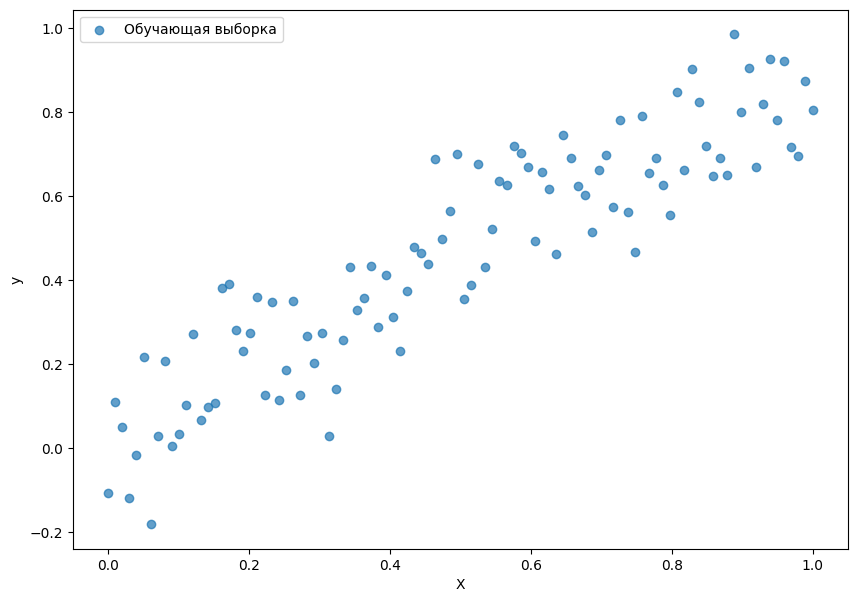

In [9]:
# Функция для визуализации выборки и предсказаний
def plot_sample_model(X, y, plot_predictions = False, y_pred = None, y_pred_label = None, loss = 'mse'):
    plt.figure(figsize = (10, 7))
    plt.scatter(X, y, label = 'Обучающая выборка', alpha = 0.7)
    if plot_predictions:
        plt.plot(X, y_pred, label = y_pred_label, c = 'r')
        if loss == 'mse':
            plt.title('MSE: ' + str(mean_squared_error(y, y_pred)))
        elif loss == 'mae':
            plt.title('MAE: ' + str(mean_absolute_error(y, y_pred)))
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend();
    
plot_sample_model(X, y, plot_predictions = False)

**Шаг 0.** Имеем пустую композицию решающих деревьев $a(X) = \{\}$.

In [10]:
a = 0

**Шаг 1.** Обучим первое решающее дерево $DT_1$ и включим его в композицию: $a^{(1)}(X) = DT_1$. Получим предсказания композиции на обучающей выборке.

In [11]:
from sklearn.tree import DecisionTreeRegressor

# TODO: обучите решающее дерево глубины 1 и сделайте предсказания на обучающей выборке
dt1 = DecisionTreeRegressor(max_depth = 1)
dt1.fit(X, y)
dt1_pred = dt1.predict(X)

# TODO: включите предсказания первого дерева в композицию (простым суммированием)
a = 0 + dt1_pred

In [12]:
dt1

DecisionTreeRegressor(max_depth=1)

In [14]:
dt1_pred

array([0.19432774, 0.19432774, 0.19432774, 0.19432774, 0.19432774,
       0.19432774, 0.19432774, 0.19432774, 0.19432774, 0.19432774,
       0.19432774, 0.19432774, 0.19432774, 0.19432774, 0.19432774,
       0.19432774, 0.19432774, 0.19432774, 0.19432774, 0.19432774,
       0.19432774, 0.19432774, 0.19432774, 0.19432774, 0.19432774,
       0.19432774, 0.19432774, 0.19432774, 0.19432774, 0.19432774,
       0.19432774, 0.19432774, 0.19432774, 0.19432774, 0.19432774,
       0.19432774, 0.19432774, 0.19432774, 0.19432774, 0.19432774,
       0.19432774, 0.19432774, 0.19432774, 0.6639547 , 0.6639547 ,
       0.6639547 , 0.6639547 , 0.6639547 , 0.6639547 , 0.6639547 ,
       0.6639547 , 0.6639547 , 0.6639547 , 0.6639547 , 0.6639547 ,
       0.6639547 , 0.6639547 , 0.6639547 , 0.6639547 , 0.6639547 ,
       0.6639547 , 0.6639547 , 0.6639547 , 0.6639547 , 0.6639547 ,
       0.6639547 , 0.6639547 , 0.6639547 , 0.6639547 , 0.6639547 ,
       0.6639547 , 0.6639547 , 0.6639547 , 0.6639547 , 0.66395

In [15]:
pd.DataFrame([dt1_pred]).T[0].unique()

array([0.19432774, 0.6639547 ])

In [18]:
pd.DataFrame([y]).T[0].unique()

array([-0.10856306,  0.10983538,  0.0484985 , -0.12033108, -0.01746698,
        0.21562724, -0.18209896,  0.02775691,  0.20731379,  0.00410988,
        0.03294981,  0.10141173,  0.27005449,  0.06704588,  0.09654508,
        0.10750097,  0.38150652,  0.38955313,  0.28122347,  0.22936184,
        0.27438571,  0.35960724,  0.12681436,  0.34782186,  0.11466862,
        0.18607477,  0.35032818,  0.12649084,  0.2650658 ,  0.20258248,
        0.27285187,  0.02818028,  0.14047984,  0.25720697,  0.42946911,
        0.3288531 ,  0.35595975,  0.43391963,  0.28652867,  0.41219177,
        0.31259996,  0.22963713,  0.3725405 ,  0.47819548,  0.46381527,
        0.43787092,  0.6873433 ,  0.49840508,  0.56394791,  0.69880154,
        0.35444311,  0.38878788,  0.67580273,  0.43033887,  0.52177505,
        0.63434698,  0.62504087,  0.719959  ,  0.70247941,  0.66824245,
        0.49236324,  0.65739318,  0.61754795,  0.46164824,  0.7440981 ,
        0.69112379,  0.62291881,  0.60296717,  0.51428894,  0.66

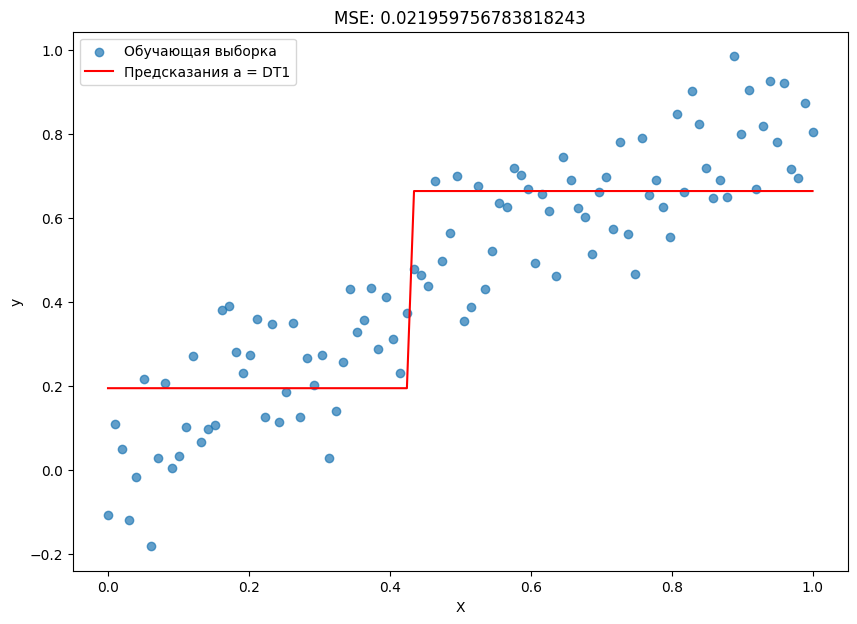

In [19]:
# Визуализация выборки и предсказаний
plot_sample_model(X, y, plot_predictions = True, y_pred = a, y_pred_label = 'Предсказания a = DT1')

**Шаг 2.** В качестве ошибок композиции будем использовать **остатки** – 
расстояния от предсказаний композиции до истинных ответов:

$$
s^{(1)}(X) = y - a^{(1)}(X)
$$

Заметим, что $MSE$ – это усреднённая сумма квадратов остатков и что остатки являются естественным выражением ошибки: если мы прибавим остатки к ответам модели, то добьёмся нулевой среднеквадратичной ошибки. Таким образом, логично строить следующую модель так, чтобы она хорошо предсказывала остатки композиции: если мы прибавим предсказания второй модели (предсказанные остатки) к предскзазаниям первой, то добьёмся снижения ошибки.

In [20]:
# TODO: рассчитайте остатки  
s1 = y - a

In [21]:
s1

array([-0.3028908 , -0.08449236, -0.14582925, -0.31465882, -0.21179472,
        0.02129949, -0.3764267 , -0.16657084,  0.01298605, -0.19021786,
       -0.16137794, -0.09291601,  0.07572674, -0.12728186, -0.09778266,
       -0.08682677,  0.18717878,  0.19522538,  0.08689573,  0.0350341 ,
        0.08005797,  0.1652795 , -0.06751339,  0.15349412, -0.07965913,
       -0.00825298,  0.15600043, -0.06783691,  0.07073806,  0.00825474,
        0.07852412, -0.16614746, -0.05384791,  0.06287923,  0.23514136,
        0.13452536,  0.16163201,  0.23959188,  0.09220092,  0.21786403,
        0.11827222,  0.03530938,  0.17821276, -0.18575923, -0.20013943,
       -0.22608378,  0.0233886 , -0.16554962, -0.10000679,  0.03484684,
       -0.30951159, -0.27516682,  0.01184803, -0.23361583, -0.14217965,
       -0.02960772, -0.03891383,  0.0560043 ,  0.0385247 ,  0.00428775,
       -0.17159147, -0.00656153, -0.04640675, -0.20230646,  0.08014339,
        0.02716909, -0.04103589, -0.06098753, -0.14966576, -0.00

**Шаг 3.** Обучим второе решающее дерево $DT_2$, предсказывающее остатки. Добавим предсказания второго дерева в композицию: $a^{(2)}(X) = DT_1 + DT_2$. Получим предсказания композиции на обучающей выборке.

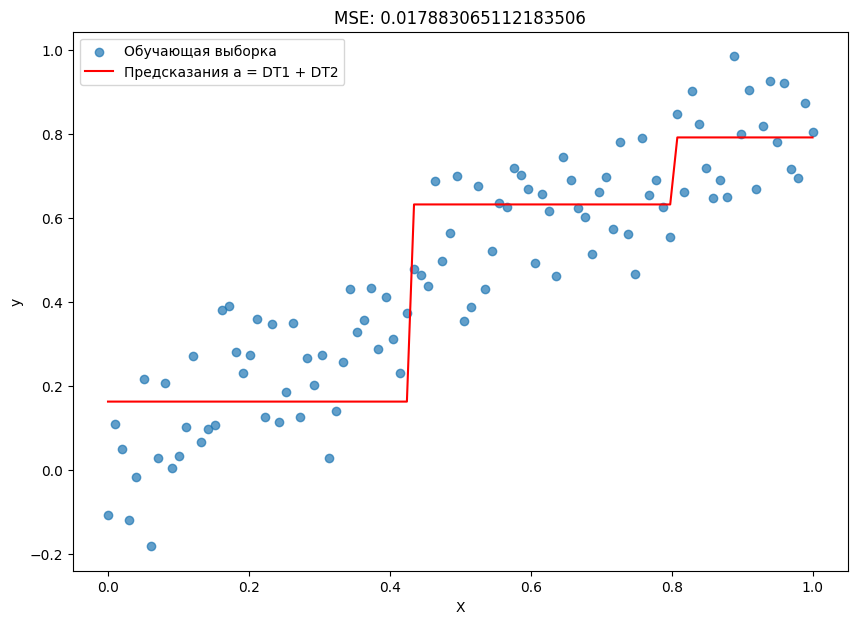

In [22]:
# TODO: обучите второе решающее дерево глубины 1, предсказывающее остатки
dt2 = DecisionTreeRegressor(max_depth = 1)
dt2.fit(X, s1)

# TODO: сделайте предсказания на обучающей выборке
dt2_pred = dt2.predict(X)

# TODO: включите предсказания второго дерева в композицию (простым суммированием)
a += dt2_pred #~ a = a + dt2_pred

# Визуализация выборки и предсказаний
plot_sample_model(X, y, plot_predictions = True, y_pred = a, y_pred_label = 'Предсказания a = DT1 + DT2')

Как мы видим, решающая поверхность стала более сложной, и теперь она более точно приближает обучающую выборку. 

**Шаги 4 – ...** Повторяем шаги 2-3, пока не надоест.

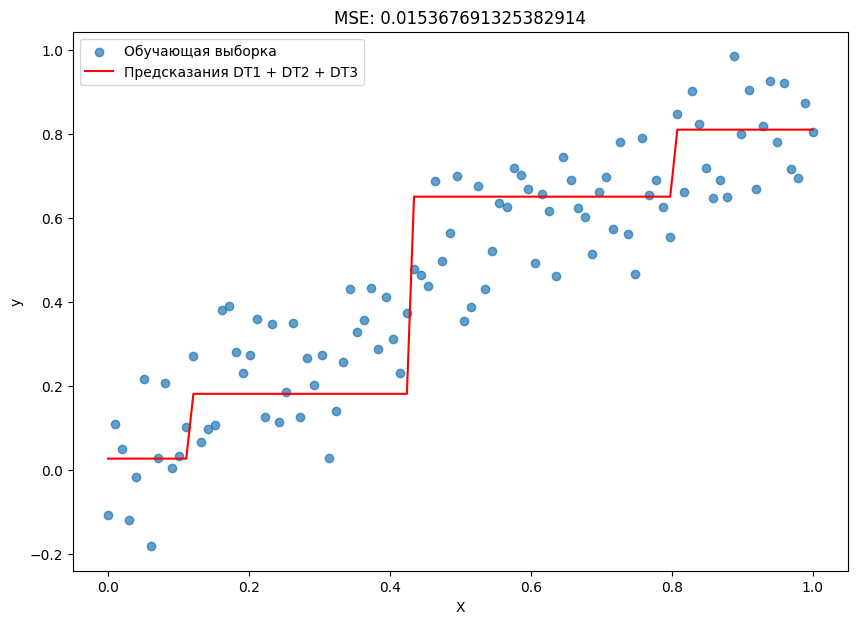

In [23]:
# TODO: рассчитайте остатки
s2 = y - a

# TODO: обучите третье решающее дерево глубины 1, предсказывающее остатки
dt3 = DecisionTreeRegressor(max_depth = 1)
dt3.fit(X, s2)

# TODO: сделайте предсказания на обучающей выборке
dt3_pred = dt3.predict(X)

# TODO: включите предсказания третьего дерева в композицию (простым суммированием)
a += dt3_pred

# Визуализация выборки и предсказаний
plot_sample_model(X, y, plot_predictions = True, y_pred = a, y_pred_label = 'Предсказания DT1 + DT2 + DT3')

Как мы видим, при добавлении базовых моделей решающая поверхность становится более сложной и всё точнее приближает обучающую выборку.

**Важный момент:** заметим, что при обучении очередной базовой модели композиция предыдущего шага считается фиксированной. Это означает, что обучение новой базовой модели не влияет на уже обученные модели, содержащиеся в композиции.

#### 1.2 Бустинг над разными моделями.

При помощи функции `plot_boosting_results()` можно визуализировать решающие поверхности композиции, очередной базовой модели и остатки при добавлении базовых моделей. 

**Задание:** посмотрите, как выглядят решающие поверхности композиции, если в качестве базовой модели использовать
- решающее дерево
- линейную регрессию
- `kNN`-регрессор
- `SVR`.

In [24]:
def plot_boosting_results(base_estimator, n_estimators, X, y):
    fig, ax = plt.subplots(n_estimators, 3, figsize = (20, n_estimators * 5))
    # Остатки
    resid = []
    resid.append(y)
    # Предсказания моделей
    y_pred = []
    for i in range(n_estimators):
        # Обучение очередной базовой модели
        base_estimator.fit(X, resid[-1]) 
        # Предсказание базовой модели
        y_pred.append(base_estimator.predict(X))
        # Вычисление предсказания композиции
        a = np.sum(y_pred, axis = 0)
        # Вычисление остатка
        resid.append(y - a)
        # Предсказания композиции
        ax[i, 0].scatter(X, y, label = 'Обучающая выборка', alpha = 0.7)
        ax[i, 0].plot(X, a, c = 'red', lw = 3, label = 'n_estimators: ' + str(i + 1))
        ax[i, 0].set_title('MSE: ' + str(mean_squared_error(y, a)))
        # Предсказания очередной модели
        ax[i, 1].scatter(X, y, label = 'Обучающая выборка', alpha = 0.7)
        ax[i, 1].plot(X, y_pred[-1], c = 'red', lw = 3)
        ax[i, 1].set_title('Предсказания модели ' + str(i + 1))
        ax[i, 2].scatter(X, resid[-1], alpha = 0.7, marker = 'v', c = 'orange')
        ax[i, 2].set_title('Остатки')
        ax[i, 0].legend()

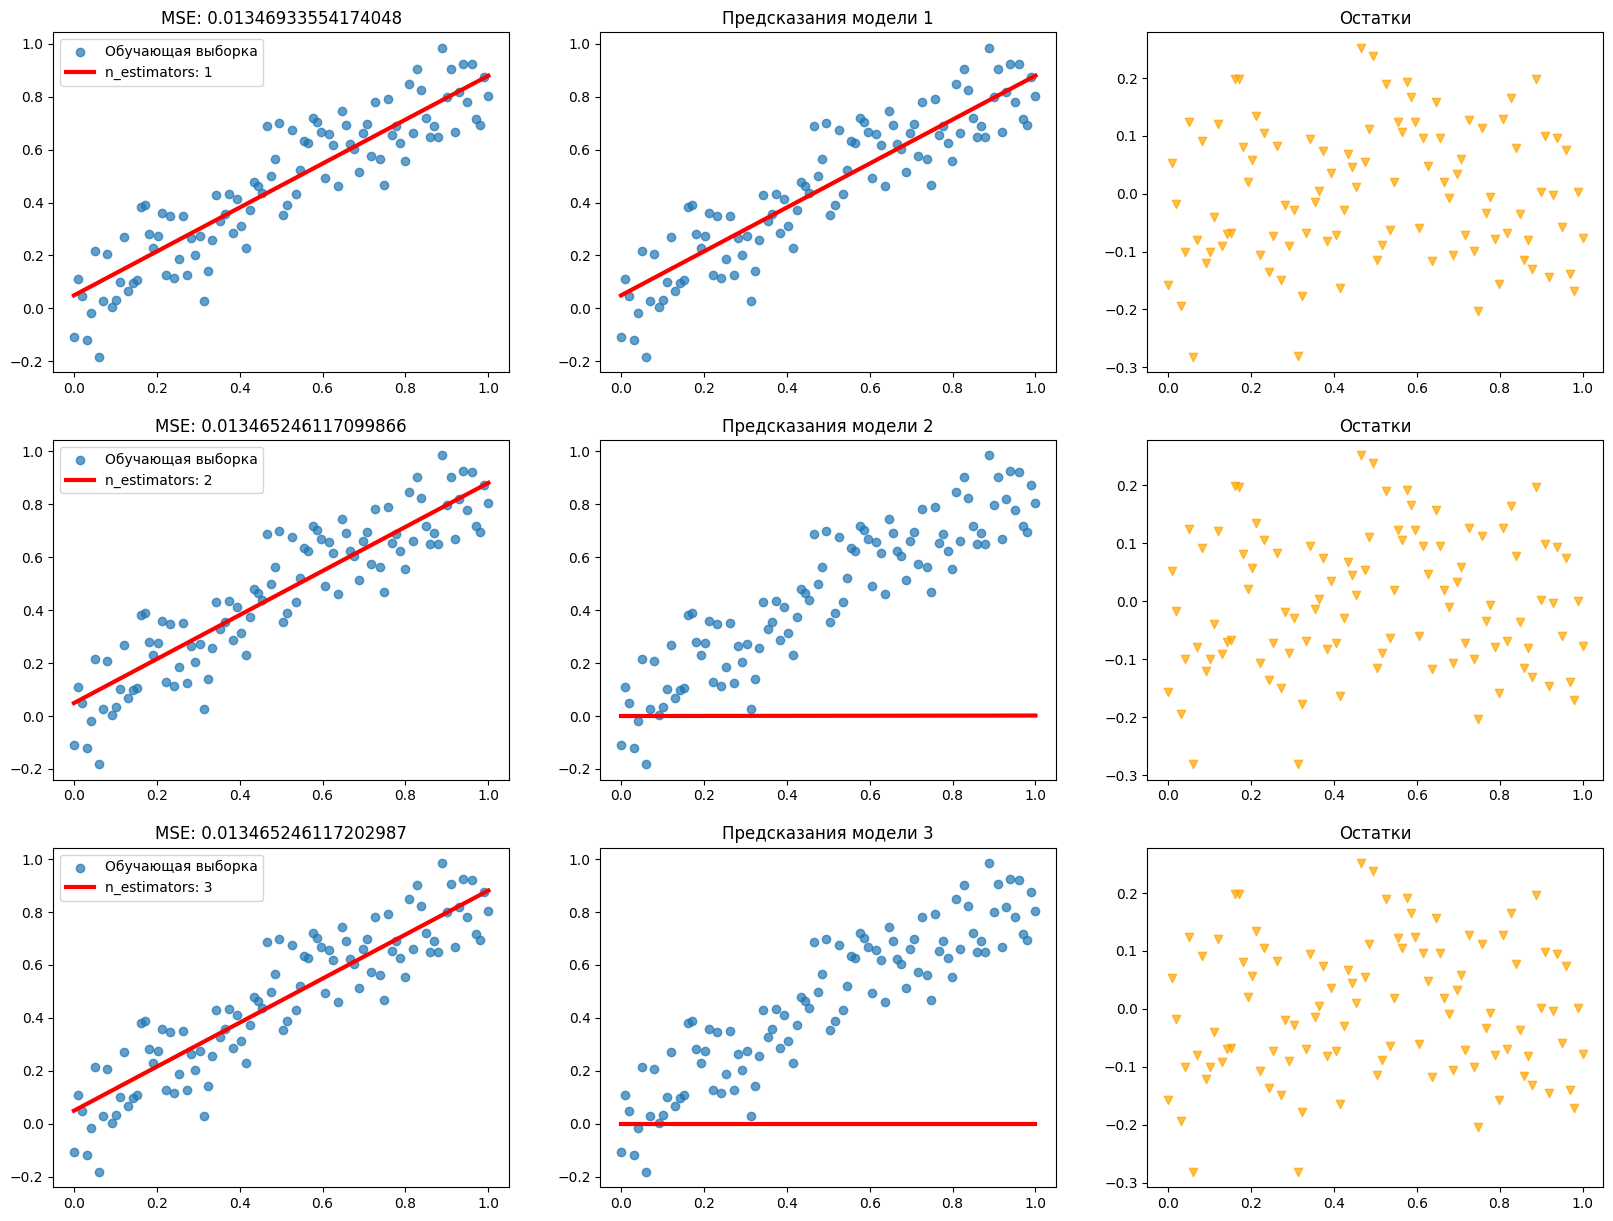

In [25]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

plot_boosting_results(SVR(kernel = 'linear'), n_estimators = 3, X = X, y = y)

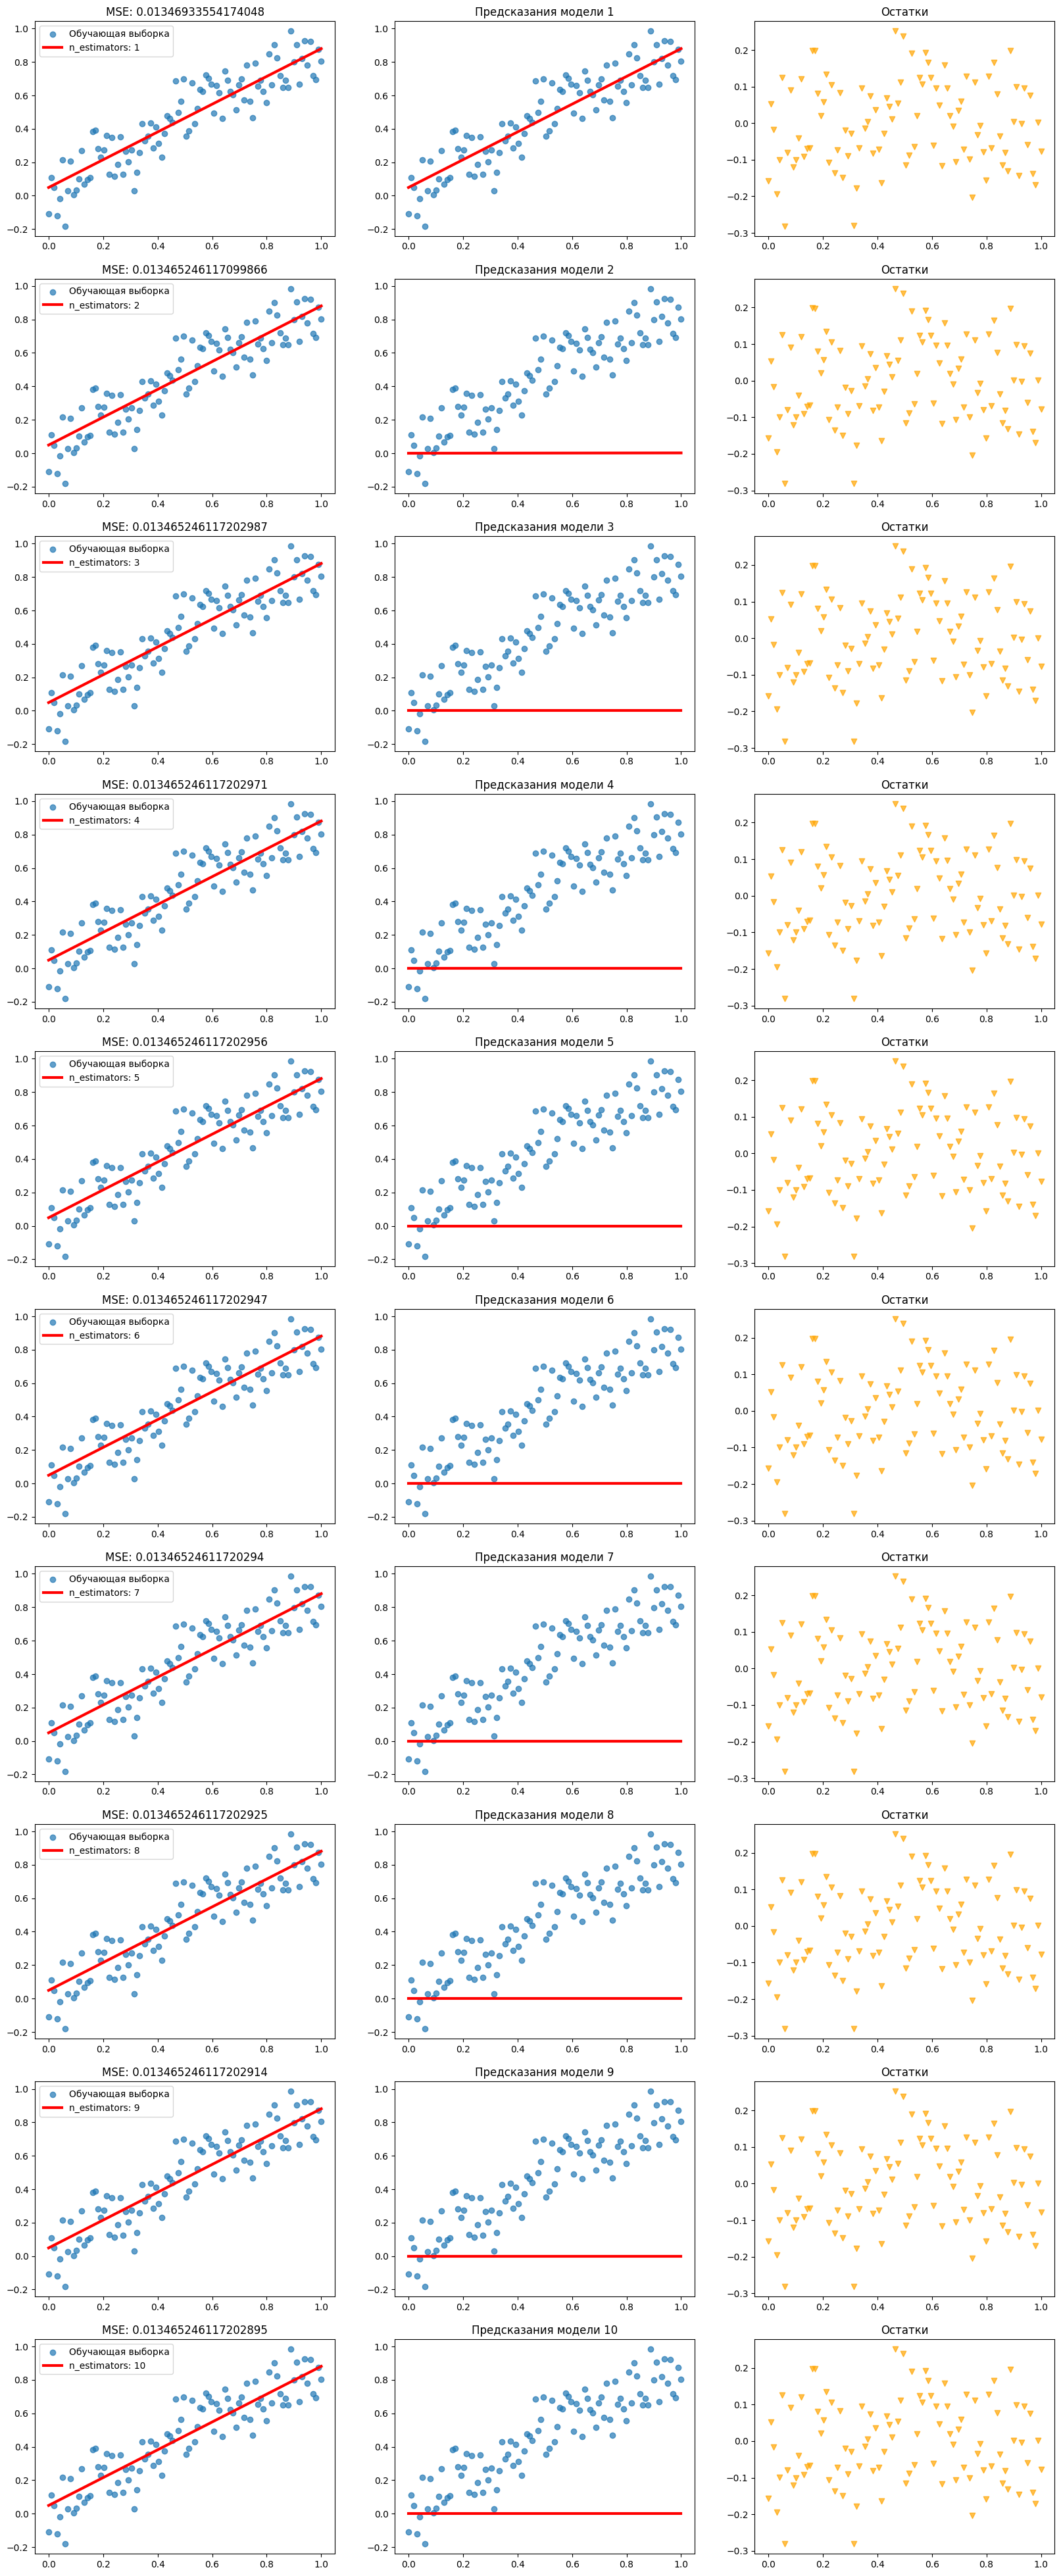

In [26]:
plot_boosting_results(SVR(kernel = 'linear'), n_estimators = 10, X = X, y = y)

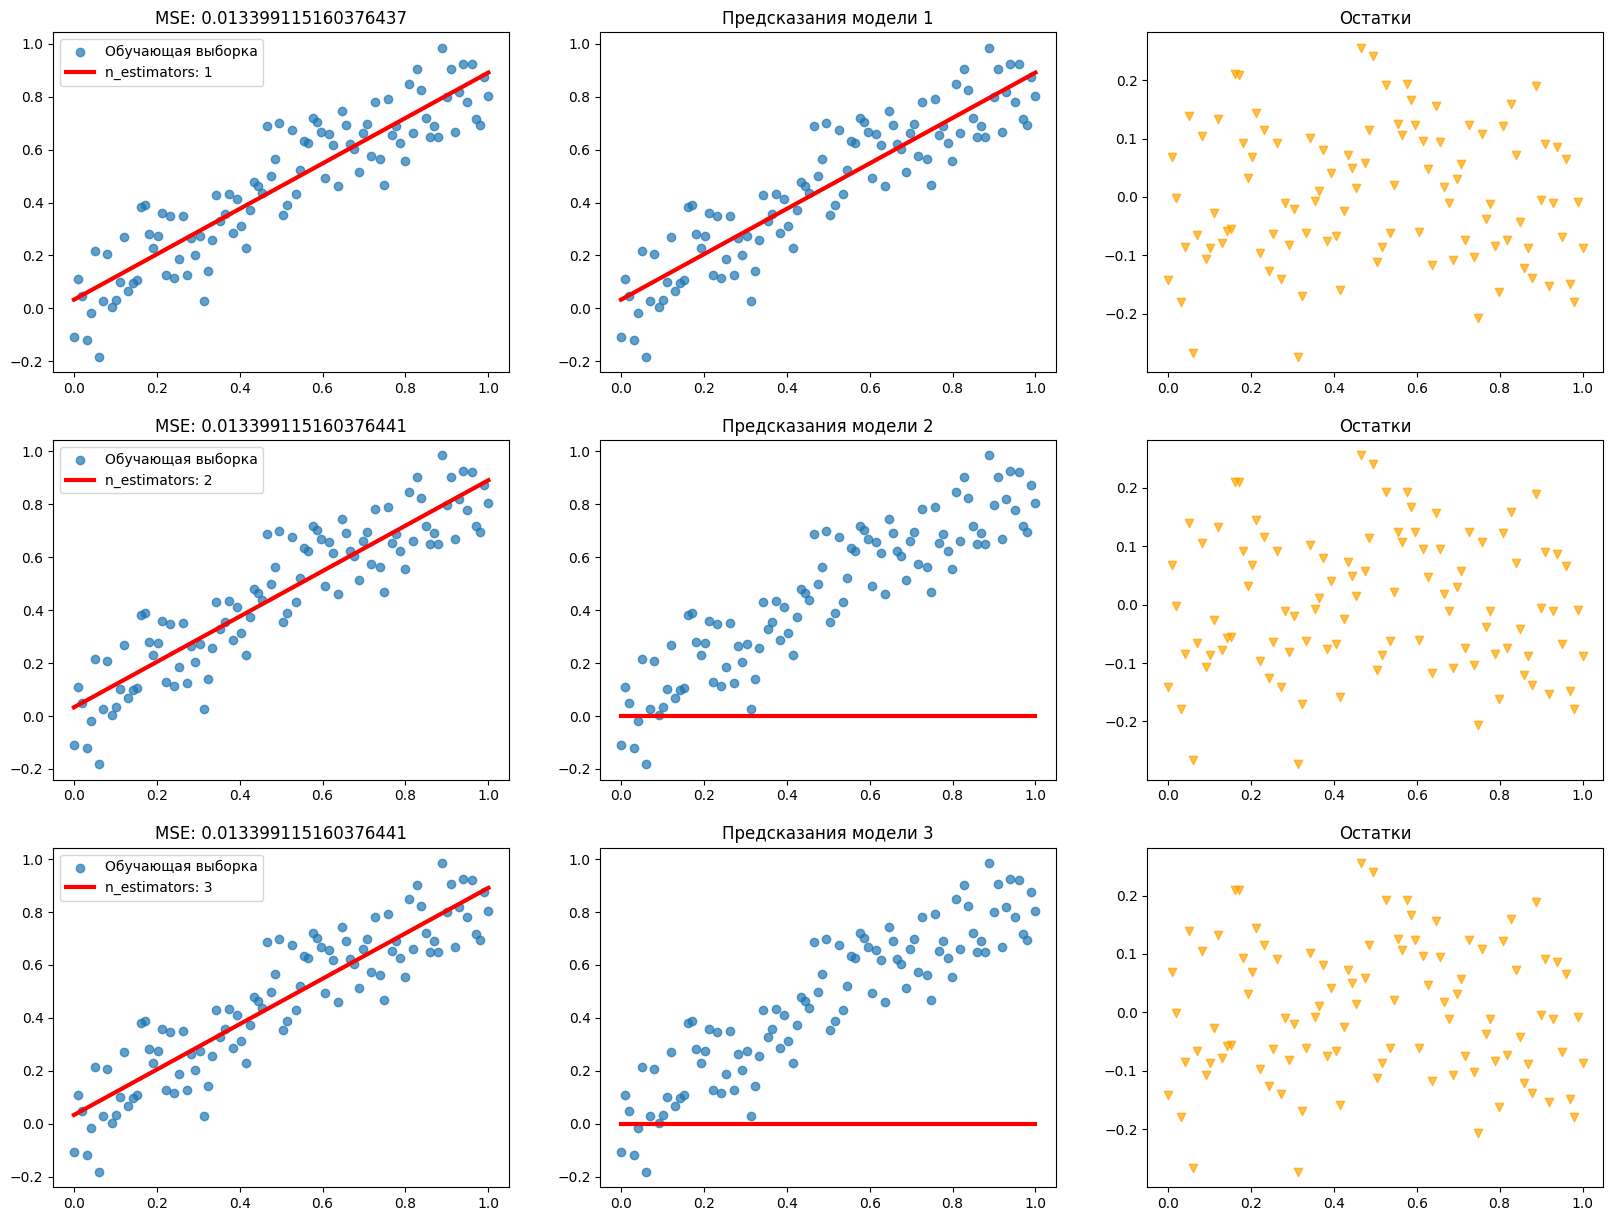

In [27]:
plot_boosting_results(LinearRegression(), n_estimators = 3, X = X, y = y)

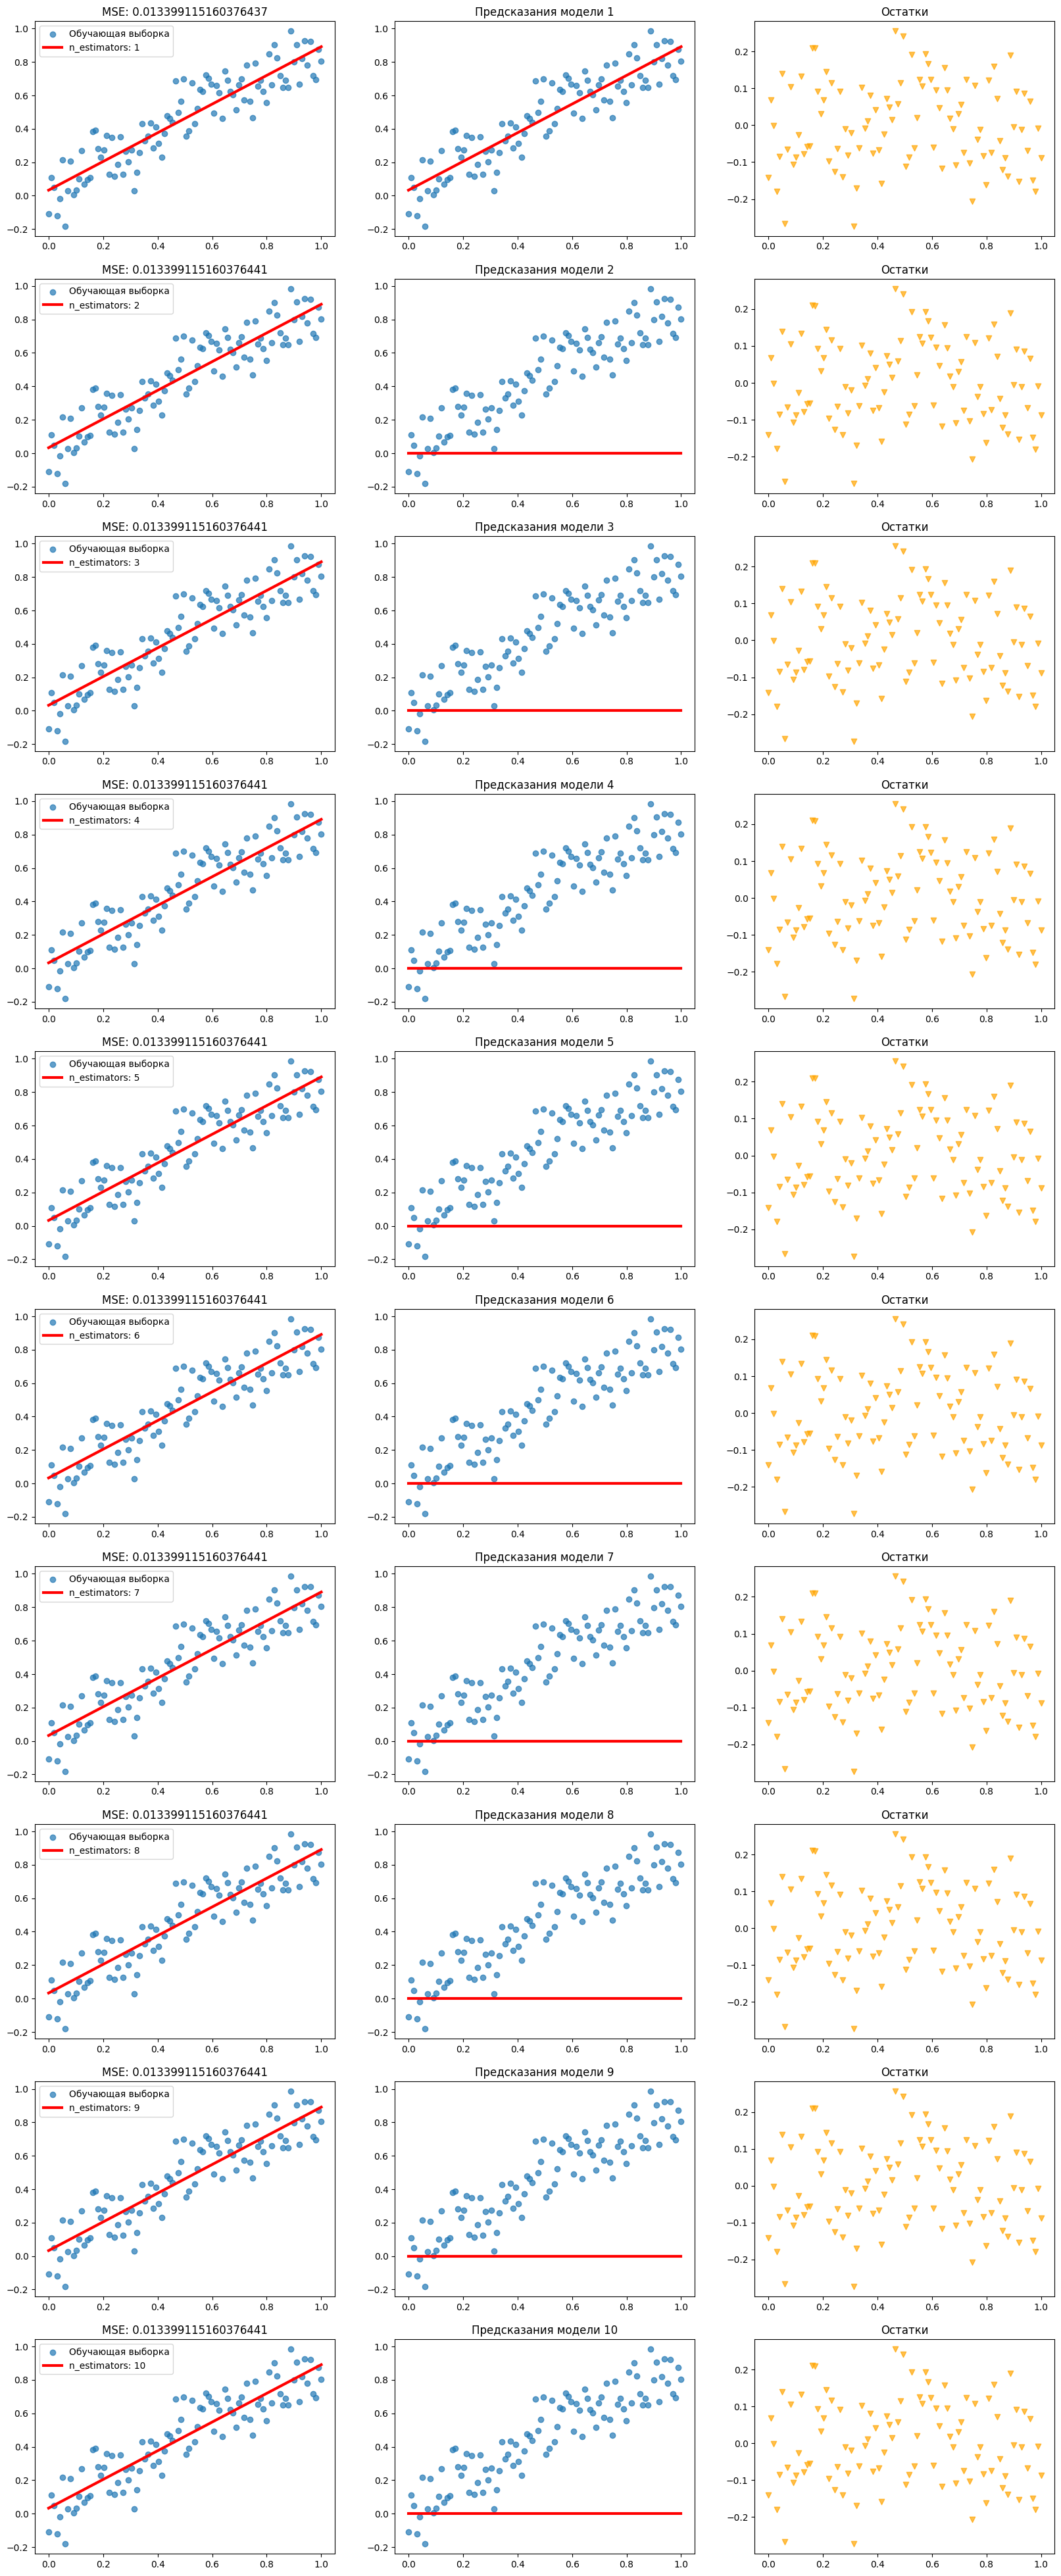

In [28]:
plot_boosting_results(LinearRegression(), n_estimators = 10, X = X, y = y)

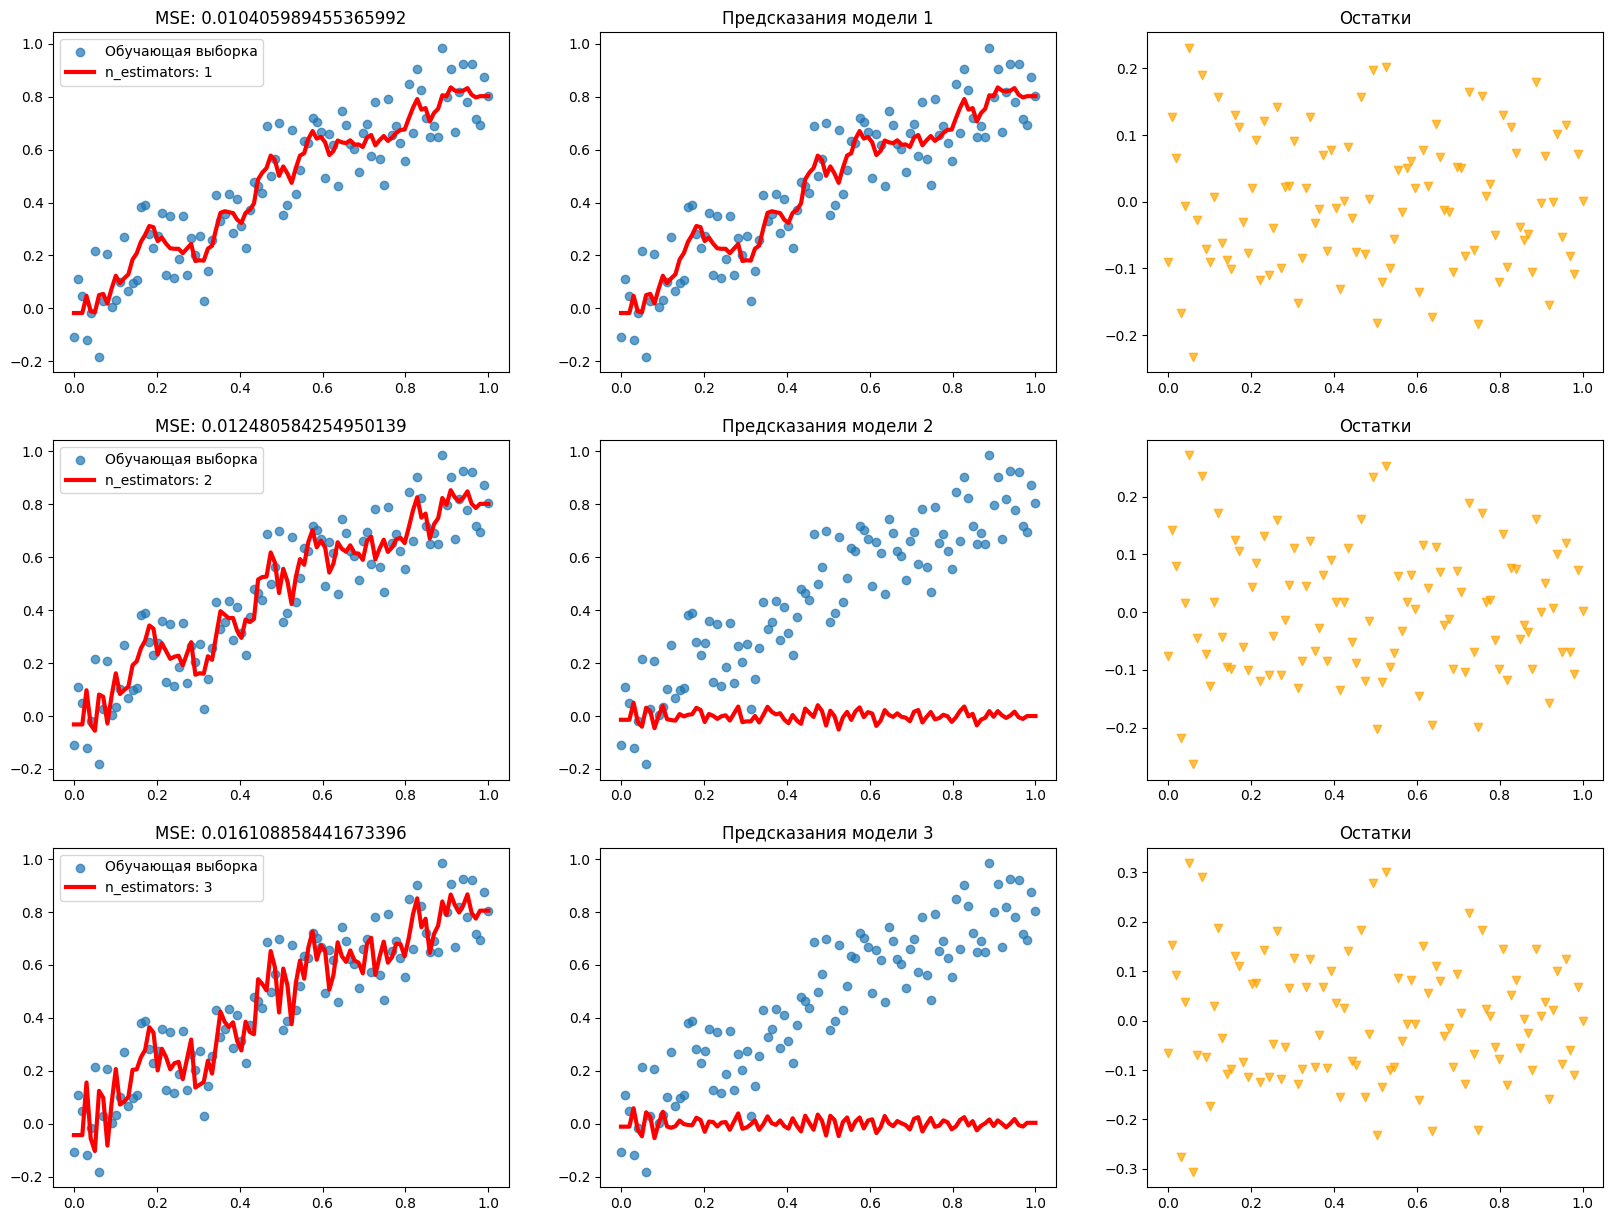

In [29]:
plot_boosting_results(KNeighborsRegressor(), n_estimators = 3, X = X, y = y)

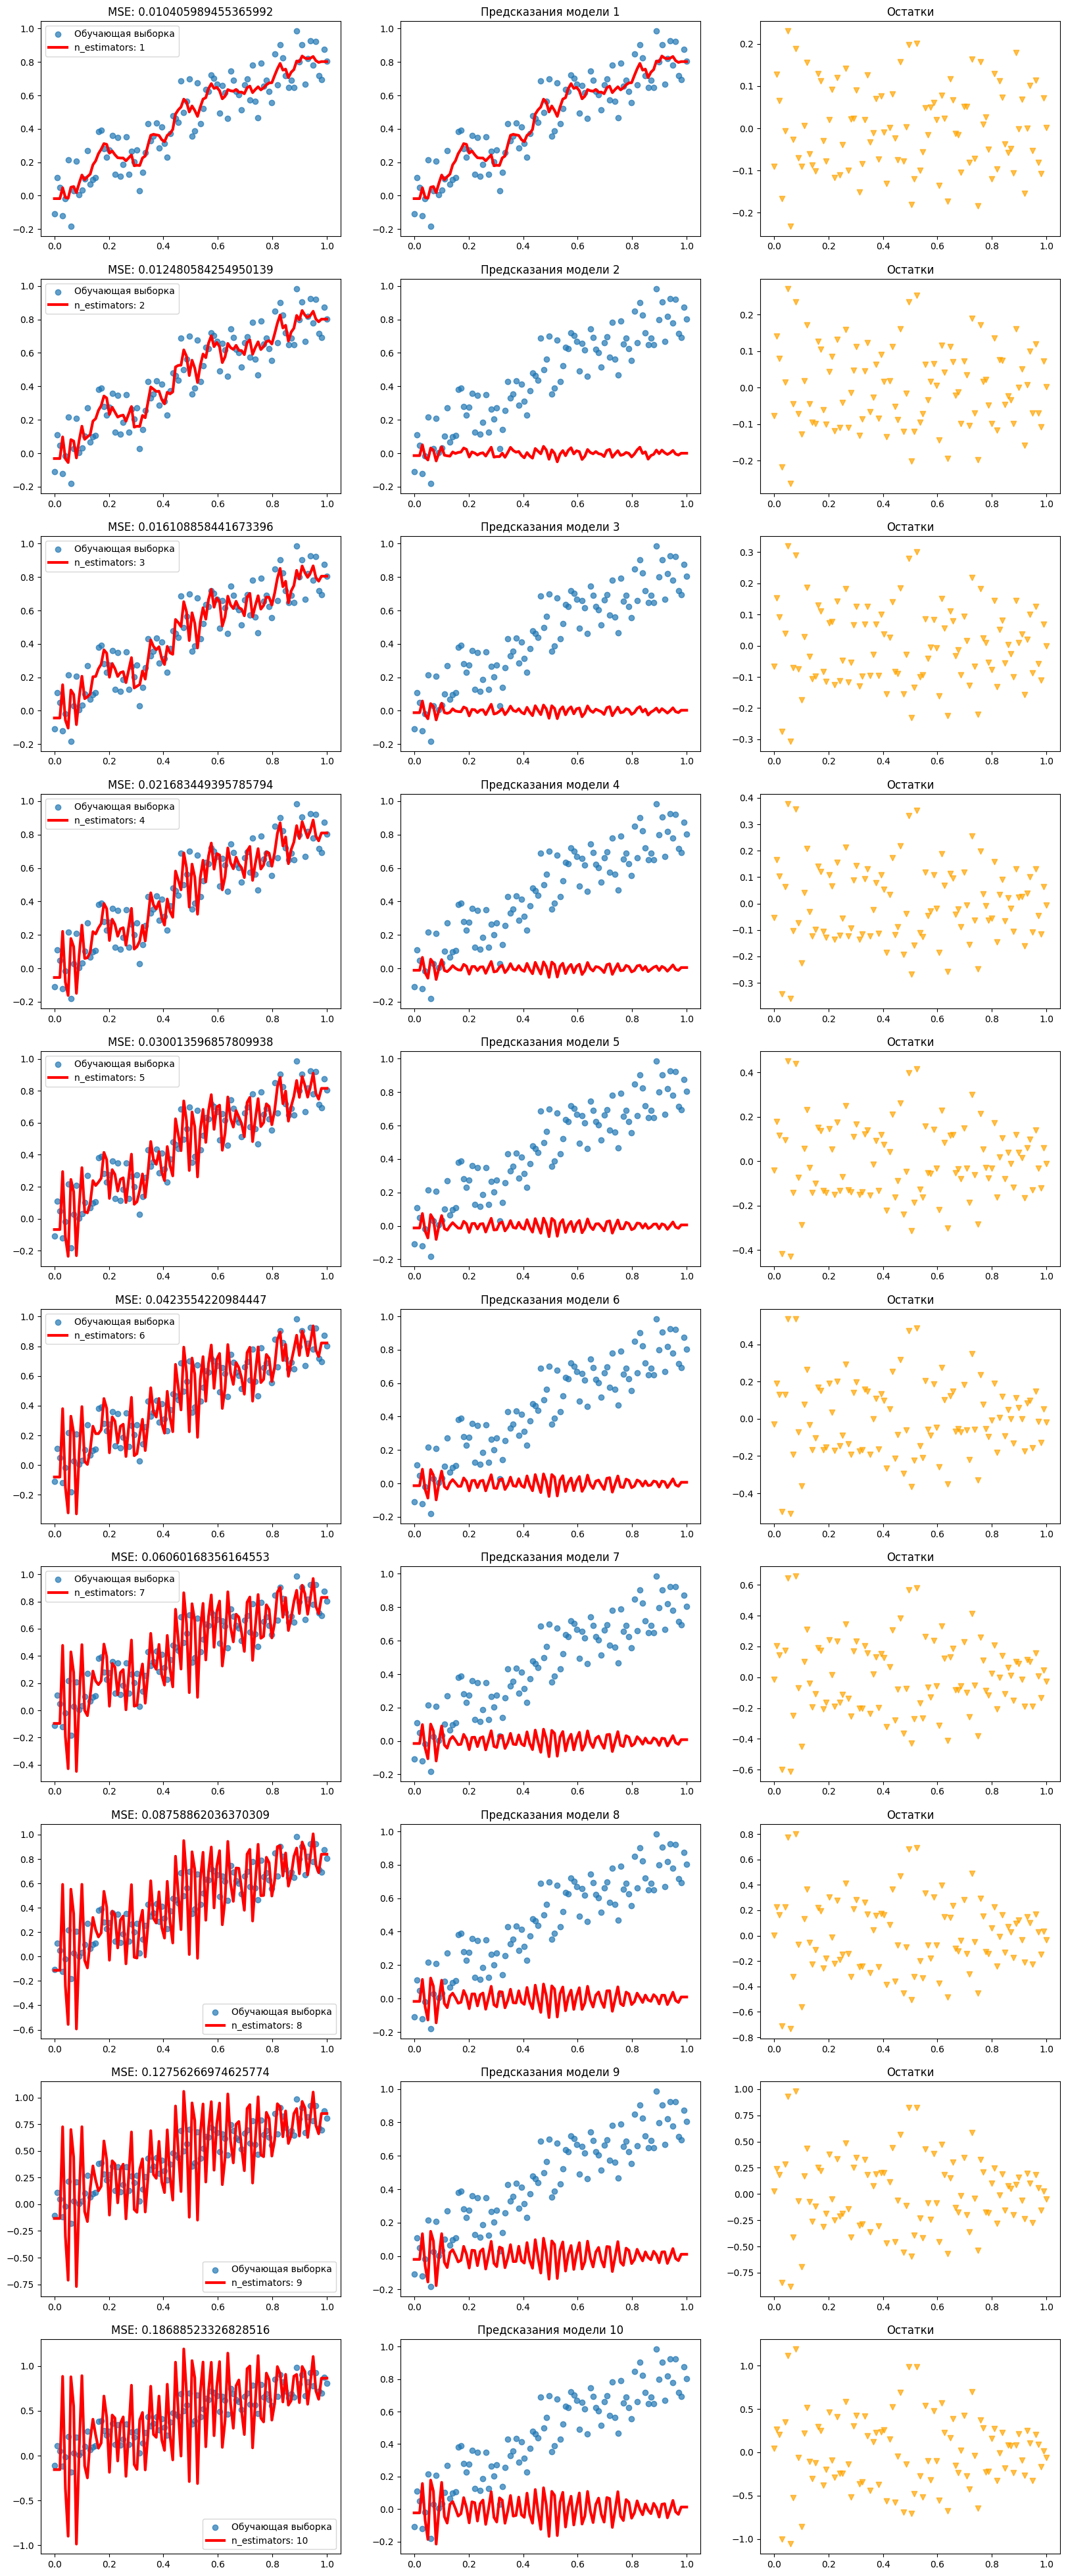

In [30]:
plot_boosting_results(KNeighborsRegressor(), n_estimators = 10, X = X, y = y)

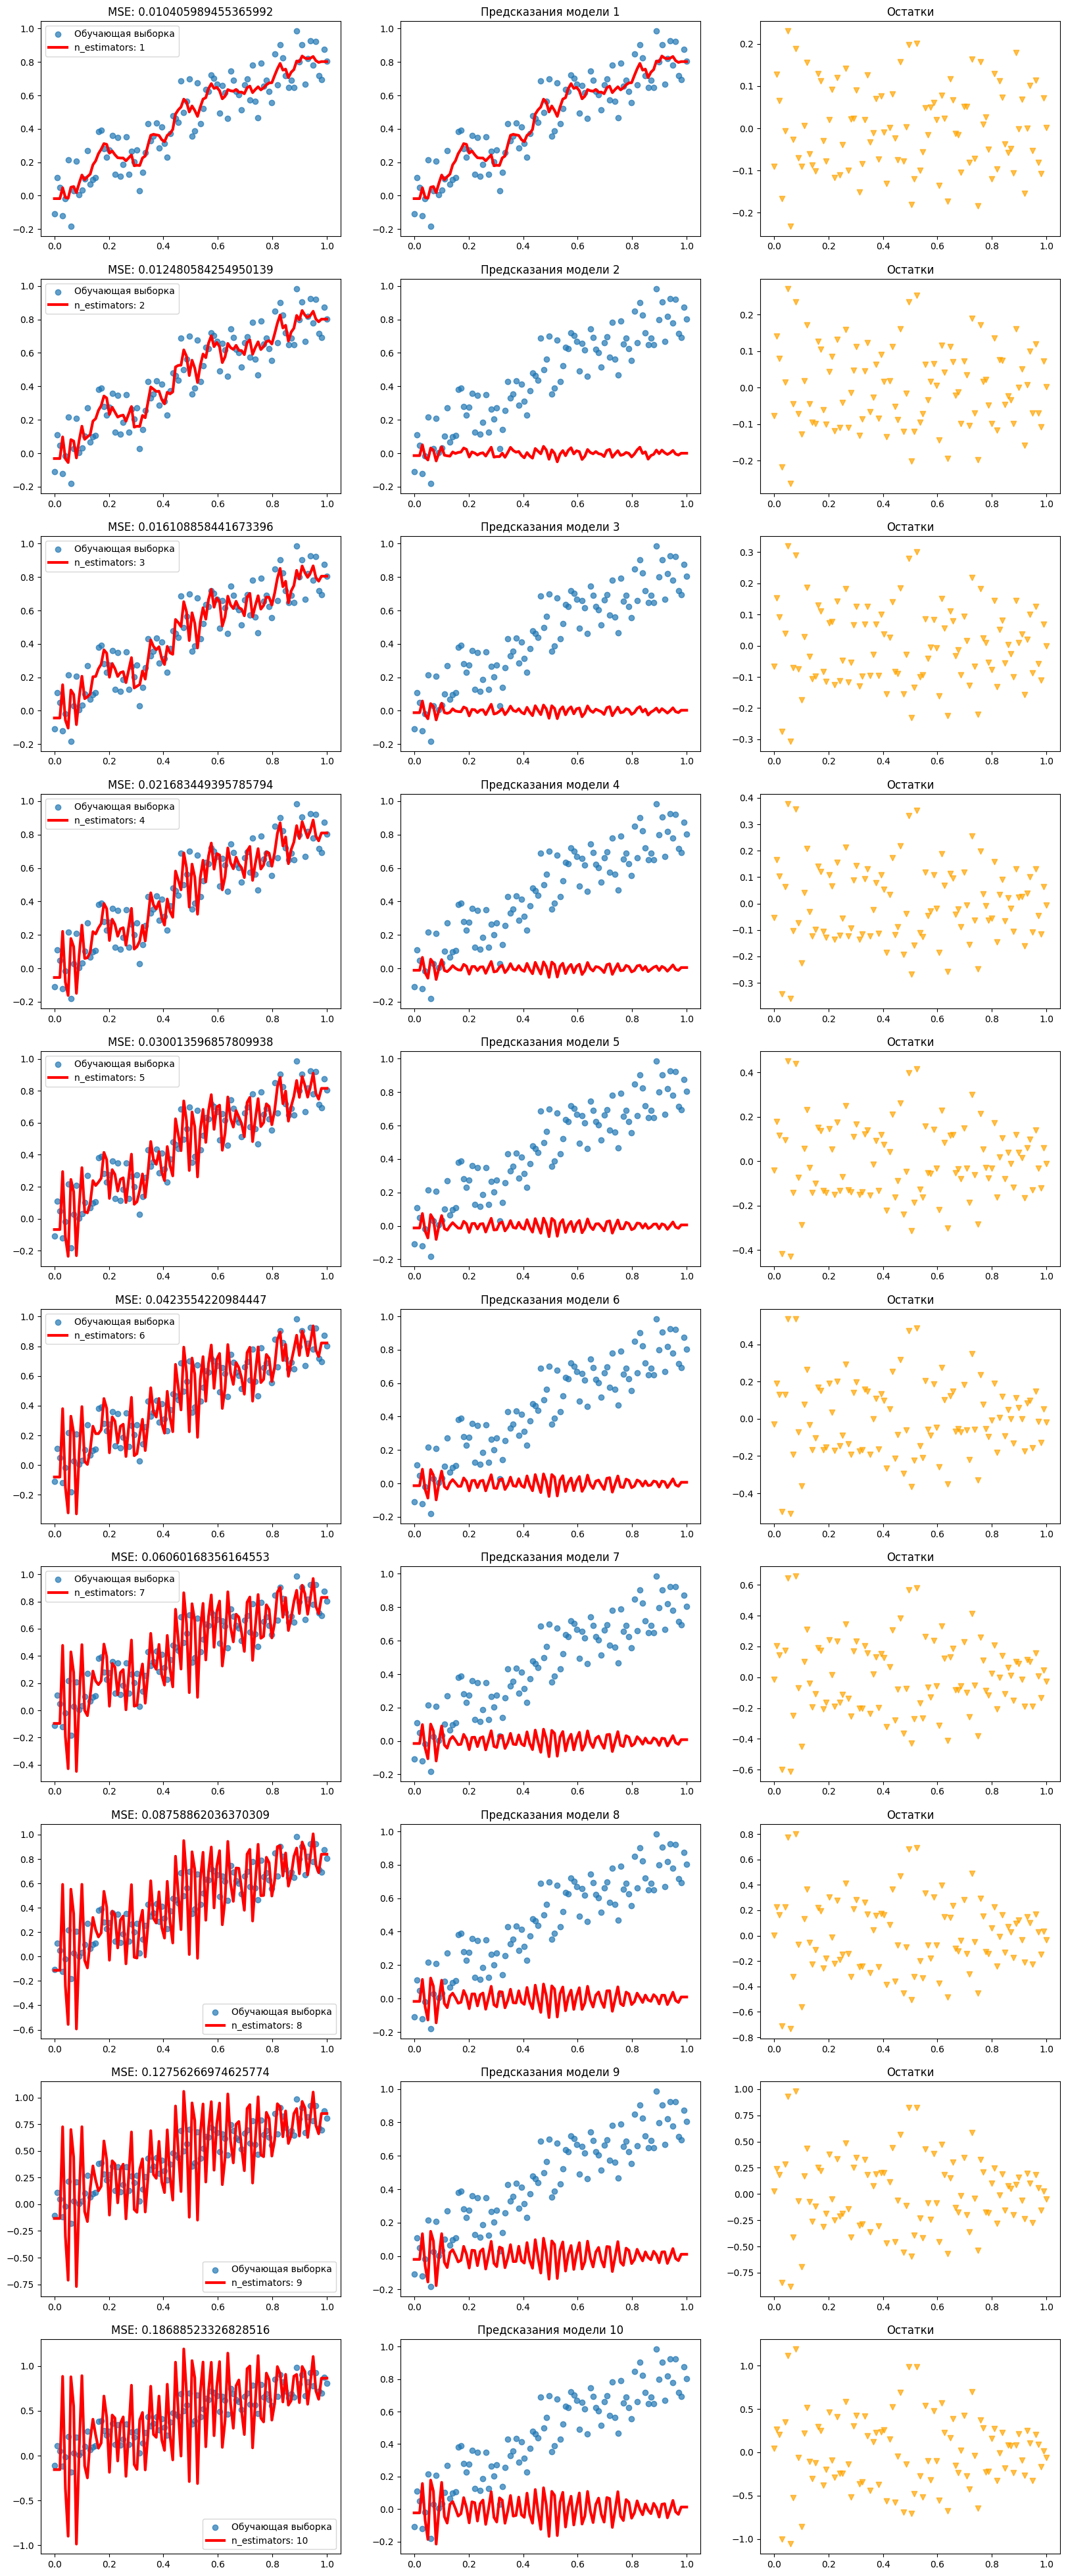

In [31]:
plot_boosting_results(KNeighborsRegressor(), n_estimators = 10, X = X, y = y)

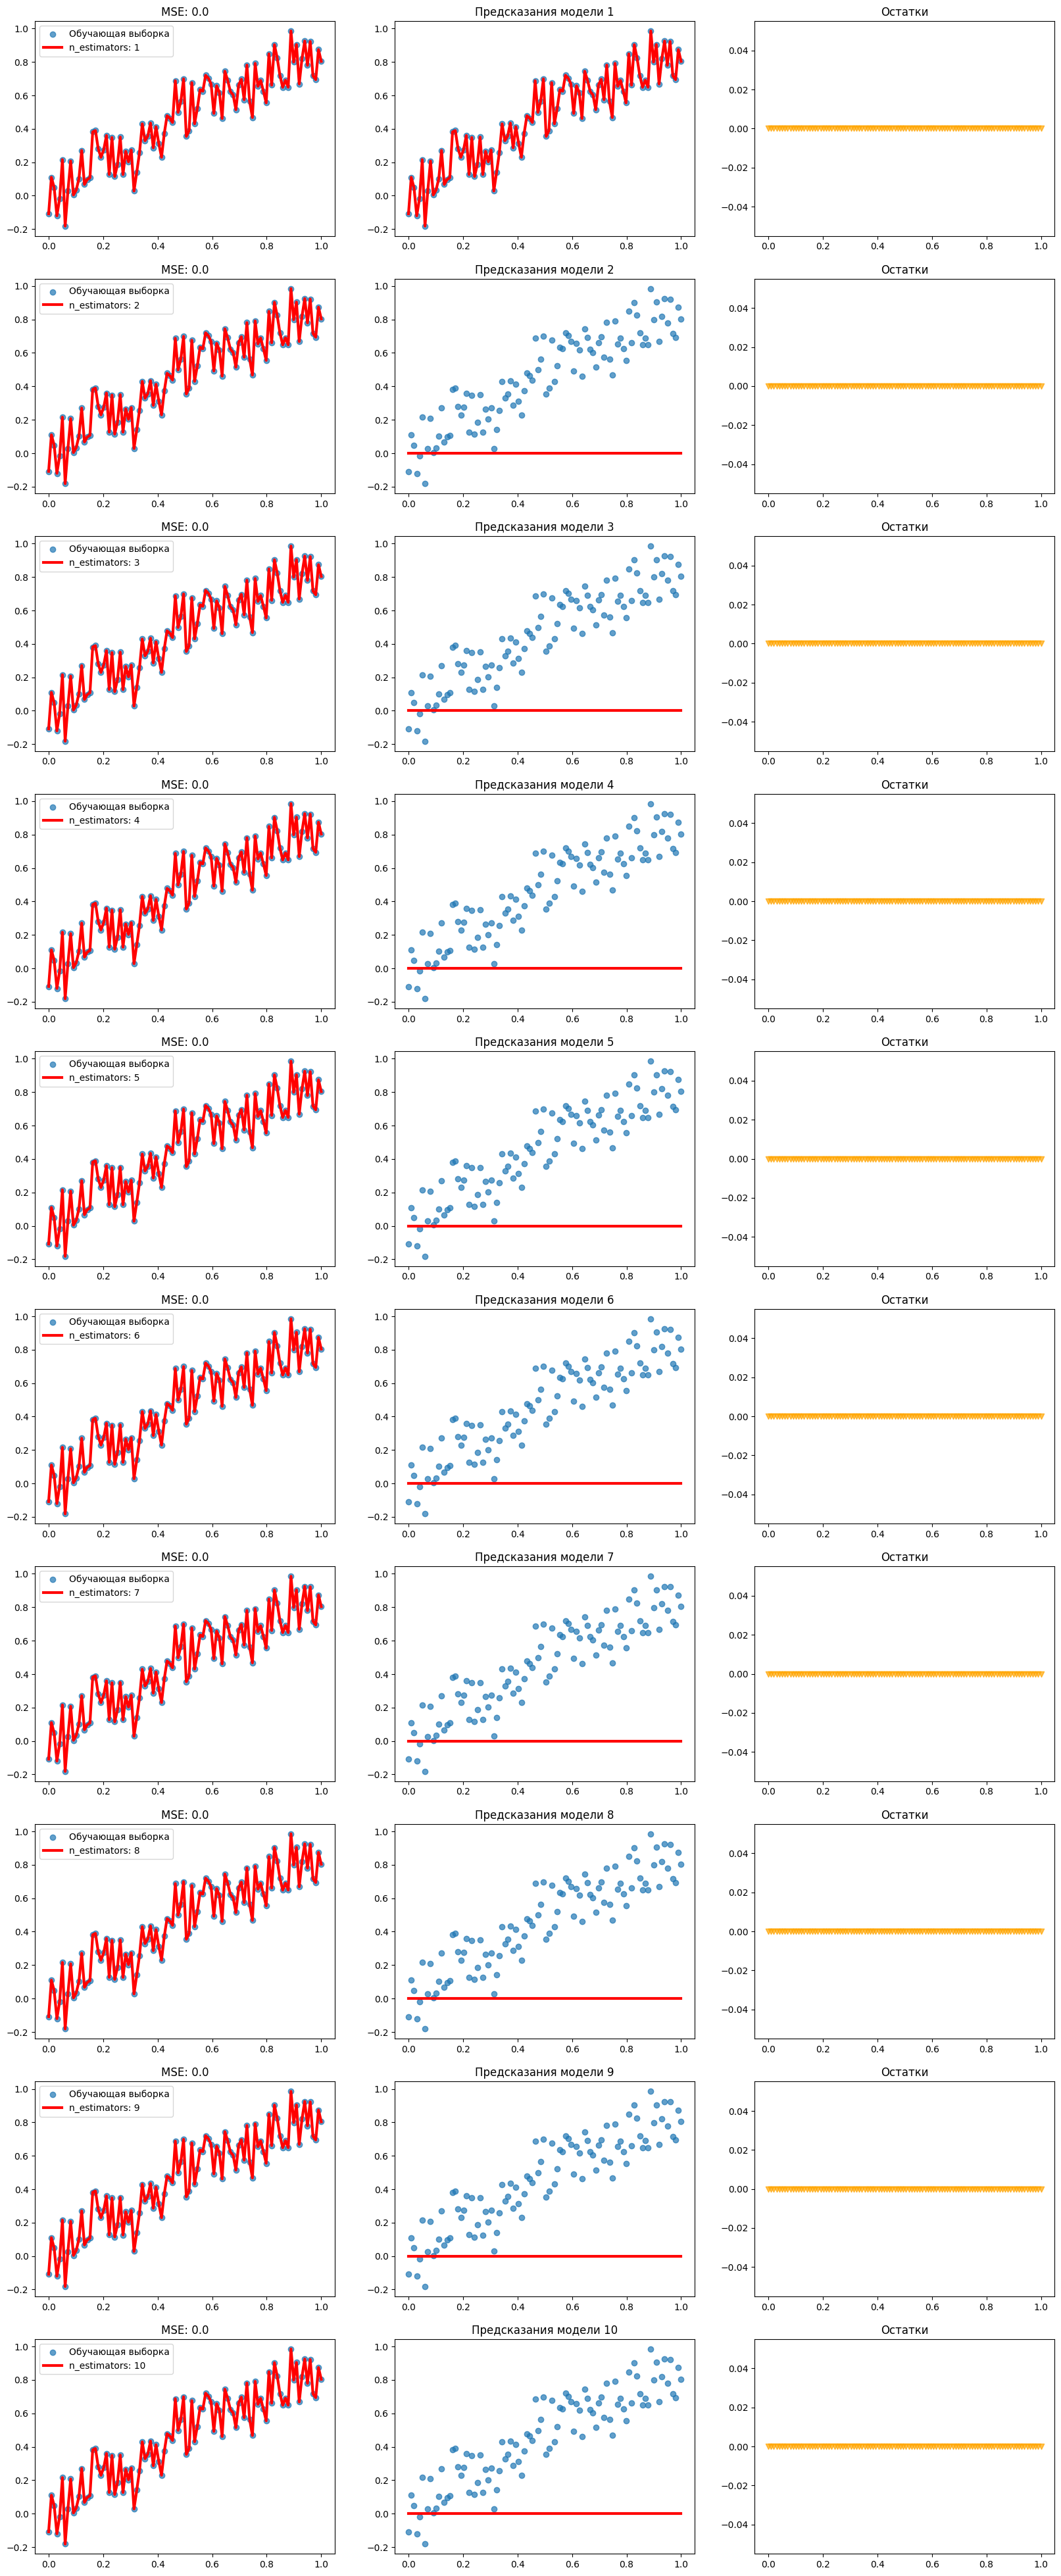

In [32]:
plot_boosting_results(DecisionTreeRegressor(), n_estimators = 10, X = X, y = y)

### 2. Градиентный бустинг

Заметим, что в примере выше использование остатков как меры ошибки модели было оправданным, так как остатки непосредственно участвуют в расчёте $MSE$. Попробуем обобщить идею использования остатков на произвольную функцию потерь.

Будем решать ту же задачу, что и выше, но с использованием произвольной функции потерь $L(\cdot)$. Предположим, что каким-то образом мы уже обучили $N$ базовых моделей и построили композицию $a^{(N)}(X)$. Как построить $(N+1)$-ю базовую модель?

Заметим, что мы хотим выбрать $(N+1)$-ую базовую модель так, чтобы как можно сильнее уменьшить ошибку:

$$
\dfrac{1}{\ell}\sum_{i = 1}^{\ell} L[y_i, a^{N}(x_i) + b^{(N+1)}(x_i)] \to \min_{b^{(N+1)}},
$$

где $b^{(N+1)}(x_i)$ – предсказания новой базовой модели. Теперь заметим, что так как и $y_i$, и $a^{N}(x_i)$ фиксированы (обсуждали выше), то в сущности нам нужно найти числа $b^{(N+1)}(x_i) = s_i^{(N)}$, которые сильнее всего уменьшили бы функцию потерь:


$$
\dfrac{1}{\ell}\sum_{i = 1}^{\ell} L[y_i, a^{N}(x_i) + s^{(N)}_i] \to \min_{s^{(N)}_i}.
$$

**Замечание.** Заметьте, что теперь мы ищем просто числа $s^{(N)}_i$, которые сильнее всего уменьшили бы функцию.

После изучения градиентного спуска мы знаем, что вектор чисел, сильнее всего уменьшающих какую-то функцию – это антиградиент этой функции. Таким образом, в качестве чисел $s_i^{(N)}$ следует взять

$$
s_i^{(N)} = -\dfrac{\partial L(y, p)}{\partial p}
$$

в точке $p = a^{(N)}(x_i)$, то есть антиградиент функции потерь в точке ответов уже построенной композиции. 

**Чек-пойнт.** Убедитесь, что вы понимаете, какие **числа**, нужно взять, чтобы решить задачу. 

Итак, мы выяснили, какие числа нужно взять для уменьшения функции потерь на **обучающей выборке**. Вспомним, что мы определяли эти числа как $b^{(N+1)}(x_i) = s_i^{(N)}$, то есть ответы очередной базовой модели. Таким образом, нам нужно обучить очередную базовую модель так, чтобы она хорошо приближала антиградиент функции потерь в точке ответов уже построенной композиции – а это хорошо известная нам задача обучения с учителем. Обычно она решается путём минимизации $MSE$:

$$
b^{(N+1)}(x) = \arg\min_b \sum_{i = 1}^{\ell} (b(x_i) - s_i^{(N)})^2.
$$

**Важный момент:** заметим, что задача, описанная выше – это не изначальная задача! В этом и состоит магия градиентного бустинга: мы можем использовать любую функцию потерь, через неё вывести $s_i^{(N)}$, а затем просто решать задачу приближения при помощи $MSE$!

#### 2.1 Продолжение простого примера для понимания идеи.

Повторим шаги из примера 1.1, используя градиентный бустинг, чтобы лучше разобраться в идее и провести параллели. Вспомним, что мы решали задачу регрессии при помощи минимизации $MSE$.

Нулевой и первый шаги в этих примерах совпадают.

**Шаг 0.** Имеем пустую композицию решающих деревьев $a(X) = \{\}$.

In [33]:
a = 0

**Шаг 1.** Обучим первое решающее дерево $DT_1$ и включим его в композицию: $a^{(1)}(X) = DT_1$. Получим предсказания композиции на обучающей выборке.

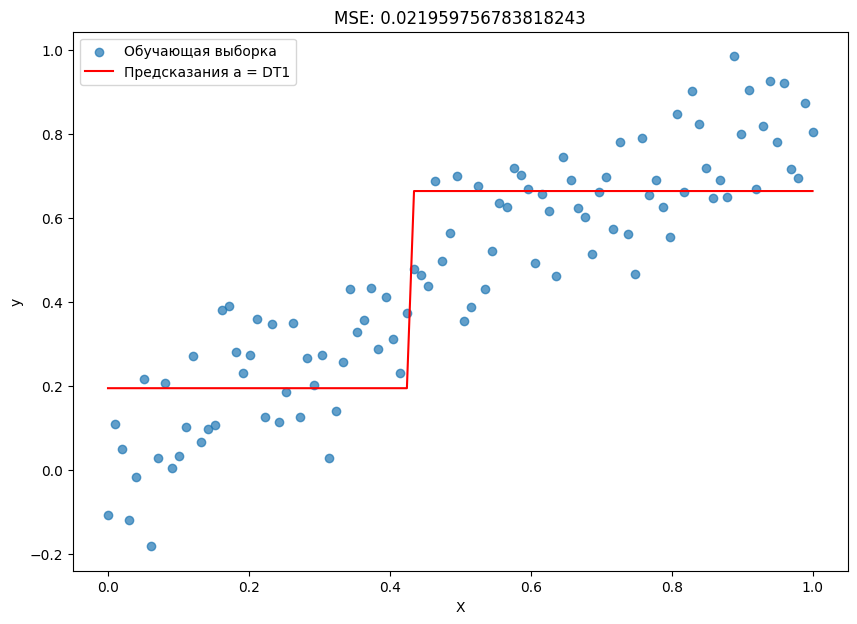

In [34]:
from sklearn.tree import DecisionTreeRegressor

# Обучение решающего дерева глубины 1 и получение предсказаний на обучающей выборке
dt1 = DecisionTreeRegressor(max_depth = 1)
dt1.fit(X, y)
dt1_pred = dt1.predict(X)

# Включение предсказаний первого дерева в композицию (простым суммированием)
a = dt1_pred

# Визуализация выборки и предсказаний
plot_sample_model(X, y, plot_predictions = True, y_pred = a, y_pred_label = 'Предсказания a = DT1')

**Шаг 2.** В примере 1.1 на этом шаге мы рассчитывали остатки. Здесь же мы должны рассчитать антиградиент функции потерь в точке ответов уже построенной композиции.

**Задание:** вычислите градиент $MSE$

$$
L(y, p) = \dfrac{1}{2} \sum_{i = 1}^{\ell} (y_i - p_i)^2
$$

по $p_i$ в точке $p_i = a(x_i)$.

**Решение:** 

$$
\dfrac{\partial L(y, p)}{\partial p_i} = -(y_i - p_i) = \{p_i = a(x_i)\} = -(y_i - a(x_i)).
$$

Таким образом, антиградиент функции потерь равен:

$$
s_i = - (-(y_i - a(x_i))) = y_i - a(x_i),
$$

то есть в точности остаток в том виде, как мы определяли выше. 

Таким образом, использование градиентного бустинга, если целевая функция – $MSE$, эквивалентно процедуре расчёта остатков, как мы это делали в примере 1.1, а сами остатки совпадают с антиградиентами $s_i$!

In [35]:
y

array([-0.10856306,  0.10983538,  0.0484985 , -0.12033108, -0.01746698,
        0.21562724, -0.18209896,  0.02775691,  0.20731379,  0.00410988,
        0.03294981,  0.10141173,  0.27005449,  0.06704588,  0.09654508,
        0.10750097,  0.38150652,  0.38955313,  0.28122347,  0.22936184,
        0.27438571,  0.35960724,  0.12681436,  0.34782186,  0.11466862,
        0.18607477,  0.35032818,  0.12649084,  0.2650658 ,  0.20258248,
        0.27285187,  0.02818028,  0.14047984,  0.25720697,  0.42946911,
        0.3288531 ,  0.35595975,  0.43391963,  0.28652867,  0.41219177,
        0.31259996,  0.22963713,  0.3725405 ,  0.47819548,  0.46381527,
        0.43787092,  0.6873433 ,  0.49840508,  0.56394791,  0.69880154,
        0.35444311,  0.38878788,  0.67580273,  0.43033887,  0.52177505,
        0.63434698,  0.62504087,  0.719959  ,  0.70247941,  0.66824245,
        0.49236324,  0.65739318,  0.61754795,  0.46164824,  0.7440981 ,
        0.69112379,  0.62291881,  0.60296717,  0.51428894,  0.66

In [36]:
pd.DataFrame(a)[0].unique()

array([0.19432774, 0.6639547 ])

In [37]:
# TODO: рассчитайте антиградиент  
s1 = y - a

In [38]:
s1

array([-0.3028908 , -0.08449236, -0.14582925, -0.31465882, -0.21179472,
        0.02129949, -0.3764267 , -0.16657084,  0.01298605, -0.19021786,
       -0.16137794, -0.09291601,  0.07572674, -0.12728186, -0.09778266,
       -0.08682677,  0.18717878,  0.19522538,  0.08689573,  0.0350341 ,
        0.08005797,  0.1652795 , -0.06751339,  0.15349412, -0.07965913,
       -0.00825298,  0.15600043, -0.06783691,  0.07073806,  0.00825474,
        0.07852412, -0.16614746, -0.05384791,  0.06287923,  0.23514136,
        0.13452536,  0.16163201,  0.23959188,  0.09220092,  0.21786403,
        0.11827222,  0.03530938,  0.17821276, -0.18575923, -0.20013943,
       -0.22608378,  0.0233886 , -0.16554962, -0.10000679,  0.03484684,
       -0.30951159, -0.27516682,  0.01184803, -0.23361583, -0.14217965,
       -0.02960772, -0.03891383,  0.0560043 ,  0.0385247 ,  0.00428775,
       -0.17159147, -0.00656153, -0.04640675, -0.20230646,  0.08014339,
        0.02716909, -0.04103589, -0.06098753, -0.14966576, -0.00

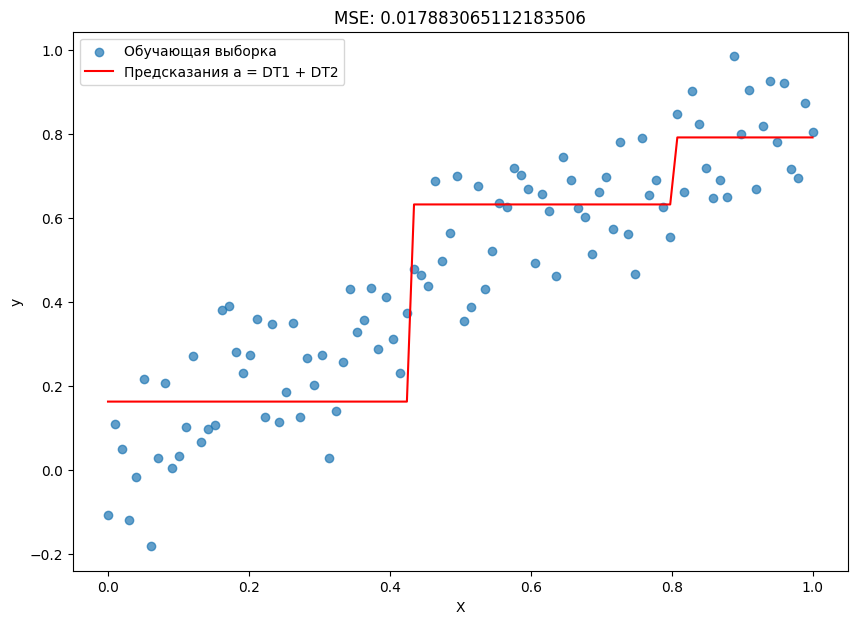

In [39]:
# Обучение второго решающего дерева глубины 1, предсказывающего антиградиент
dt2 = DecisionTreeRegressor(max_depth = 1)
dt2.fit(X, s1)

# Получение предсказаний на обучающей выборке
dt2_pred = dt2.predict(X)

# Включение предсказаний второго дерева в композицию (простым суммированием)
a += dt2_pred

# Визуализация выборки и предсказаний
plot_sample_model(X, y, plot_predictions = True, y_pred = a, y_pred_label = 'Предсказания a = DT1 + DT2')

**Шаг 3 и далее.** Далее нам нужно обучить базовую модель, предсказывающую $s_i$. Но так как $s_i$ совпадают с остатками, этот и дальнейшие шаги будут совпадать с примером 1.1.

### 3. Функции потерь градиентного бустинга для регрессии и классификации

#### 3.1 Регрессия.

В задачах регрессии в качестве целевой функции для композиции обычно берутся:

1. $MSE$, которую мы рассматривали ранее.

2. $MAE$:

$$
MAE(y, p) = \dfrac{1}{\ell} \sum_{i = 1}^{\ell} |y_i - p_i|
$$

Попробуем сделать шаг градиентного бустинга, используя в качестве функции потерь $MAE$.

**Задание:** рассчитайте $s_i$ для $MAE$.

**Решение:** $s_i^{(N)} = -\mathrm{sign}(a^{(N-1)}(x_i) - y_i)$.

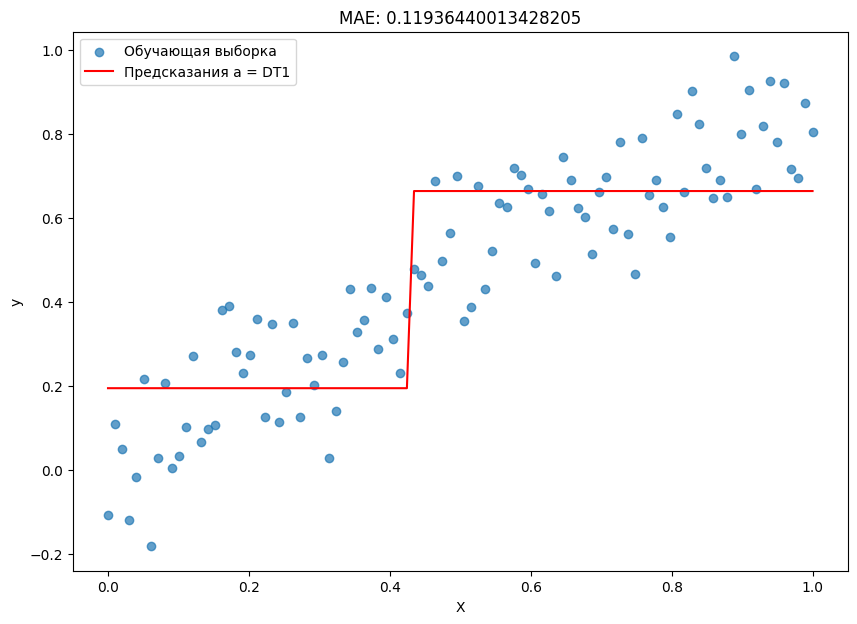

In [40]:
# Инициализация
a = 0

# Обучение решающего дерева глубины 1 и получение предсказаний на обучающей выборке
dt1 = DecisionTreeRegressor(max_depth = 1)
dt1.fit(X, y)
dt1_pred = dt1.predict(X)

# Включение предсказаний первого дерева в композицию (простым суммированием)
a = dt1_pred

# Визуализация выборки и предсказаний
plot_sample_model(X, y, plot_predictions = True, y_pred = a, y_pred_label = 'Предсказания a = DT1', loss = 'mae')

In [41]:
# TODO: рассчитайте антиградиент  
s1 = -np.sign(a - y)

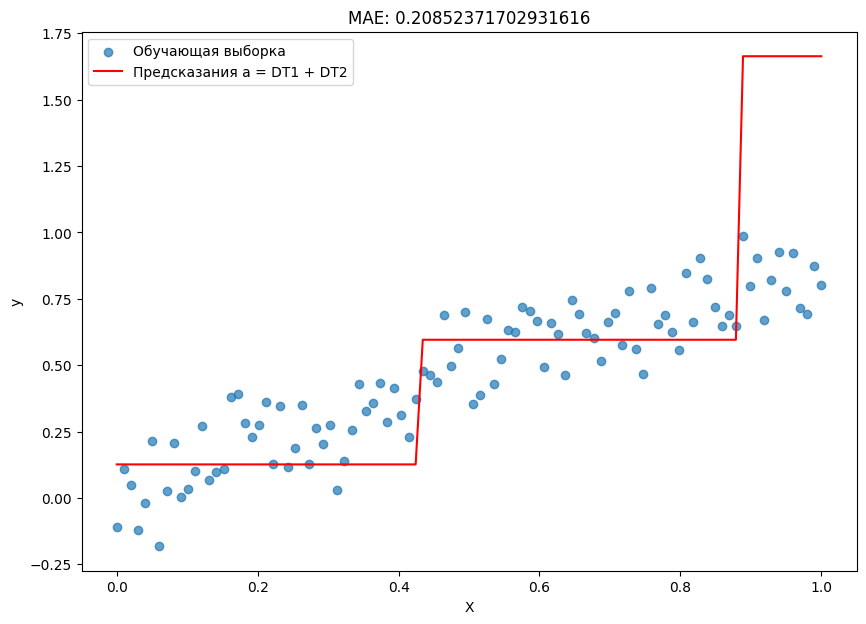

In [42]:
# Обучение второго решающего дерева глубины 1, предсказывающего антиградиент
dt2 = DecisionTreeRegressor(max_depth = 1)
dt2.fit(X, s1)

# Получение предсказаний на обучающей выборке
dt2_pred = dt2.predict(X)

# Включение предсказаний второго дерева в композицию (простым суммированием)
a += dt2_pred

# Визуализация выборки и предсказаний
plot_sample_model(X, y, plot_predictions = True, y_pred = a, 
                  y_pred_label = 'Предсказания a = DT1 + DT2', loss = 'mae')

Заметим, что $MAE$ увеличилась, а решающая поверхность имеет "виток", уходящий за пределы обучающей выборки. Эту проблему мы решим позже.

#### 3.2 Классификация.

В задачах бинарной классификации обычно используется логистическая функция потерь, с которой мы уже сталкивались в логистической регрессии.

$$
L(y, p) = \log(1 + e^{-yp}).
$$

**Бонусное задание:** покажите, что в этом случае антиградиенты можно вычислить по формуле

$$
s^{(N)}_i = \dfrac{y_i}{1 + e^{y_ia^{(N-1)}(x_i)}}
$$

Попробуем сделать шаг градиентного бустинга в задаче бинарной классификации с логистической функцией потерь.

In [43]:
from sklearn.datasets import load_iris

# Загрузка данных
data = load_iris()
X = data['data']
y = data['target']

# Перекодируем в задачу бинарной классификации
y[y == 2] = 1
set(y)

{0, 1}

In [44]:
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [45]:
# Инициализация
a = 0

# Обучение решающего дерева глубины 1 и получение предсказаний на обучающей выборке
dt1 = DecisionTreeRegressor(max_depth = 1)
dt1.fit(X, y)
dt1_pred = dt1.predict(X)

# Включение предсказаний первого дерева в композицию (простым суммированием)
a = dt1_pred

In [46]:
def log_loss(y, y_pred):
    # TODO: реализуйте логистическую функцию потерь
    return np.log(1 + np.exp(- y * y_pred)).mean()

In [47]:
# Вычисление ошибки для одного дерева
log_loss(y, a)

0.439890185198797

In [48]:
# TODO: рассчитайте антиградиент  
s1 = y / (1 + np.exp(y * a))

In [49]:
# Обучение второго решающего дерева глубины 1, предсказывающего антиградиент
dt2 = DecisionTreeRegressor(max_depth = 1)
dt2.fit(X, s1)

# Получение предсказаний на обучающей выборке
dt2_pred = dt2.predict(X)

# Включение предсказаний второго дерева в композицию (простым суммированием)
a += dt2_pred

In [50]:
# Вычисление ошибки для двух деревьев
log_loss(y, a)

0.39621023915529535

### 4. Особенности градиентного бустинга

#### 4.1 Построение композиции.

В примерах выше мы строили композицию моделей простым суммированием. Понятно, что в общем виде можно строить взвешенную сумму базовых моделей:

$$
a(X) = \sum_{n = 1}^{k} w_nb_n(X),
$$

где коэффициенты $w_n$ можно подобрать, например, при помощи градиентного спуска в задаче 

$$
w_n = \arg\min_{w} \sum_{i = 1}^{\ell} L(y_i, a^{(N-1)}(x_i) + w \times b_N(x_i)),
$$

что имеет смысл, так как $b_N(x_i)$ уже обучена и фиксирована.

**Замечание:** длина шага является одним из ключевых параметров градиентного бустинга, и может очень сильно повлиять на его производительность. Подробнее об этом [здесь](https://machinelearningmastery.com/tune-learning-rate-for-gradient-boosting-with-xgboost-in-python/).

В нашем случае подбор правильного коэффициента поможет решить увеличение MAE в примере 3.1. 

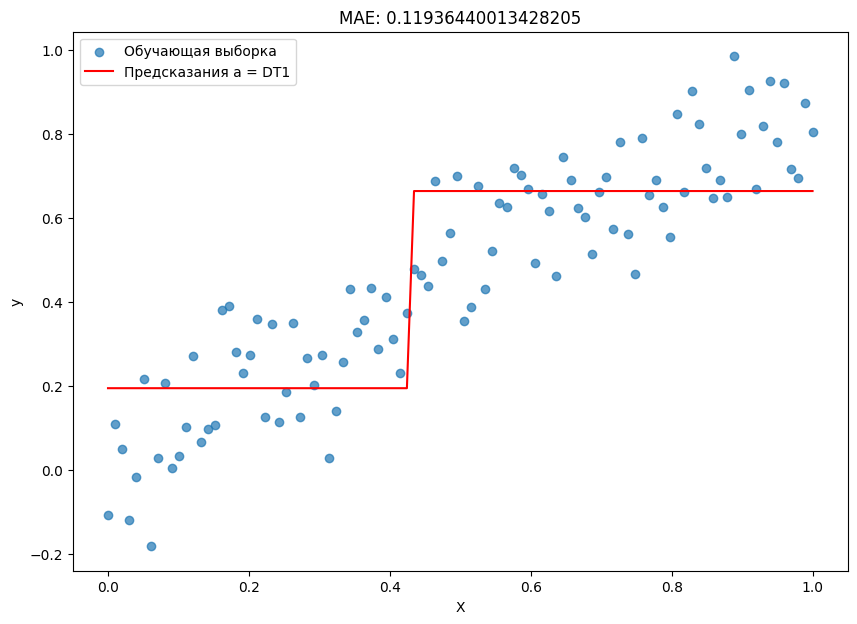

In [51]:
# Инициализация
np.random.seed(123)
N = 100
X = np.linspace(0, 1, N).reshape(-1, 1)
y = np.sin(X)[:, 0] + np.random.normal(0, 0.1, size = N)
a = 0

# Обучение решающего дерева глубины 1 и получение предсказаний на обучающей выборке
dt1 = DecisionTreeRegressor(max_depth = 1)
dt1.fit(X, y)
dt1_pred = dt1.predict(X)

# Включение предсказаний первого дерева в композицию (простым суммированием)
a = dt1_pred

# Визуализация выборки и предсказаний
plot_sample_model(X, y, plot_predictions = True, y_pred = a, y_pred_label = 'Предсказания a = DT1', loss = 'mae')

In [52]:
# Вычисление антиградиента 
s1 = -np.sign(a - y)

In [53]:
# TODO: подберите (угадайте) вес так, чтобы уменьшить MAE
w = 0.1

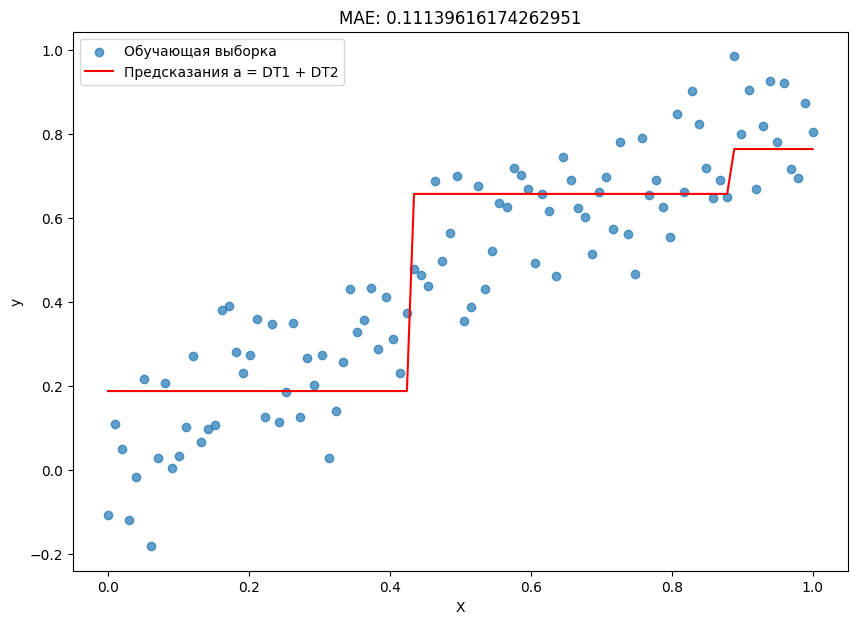

In [54]:
# Обучение второго решающего дерева глубины 1, предсказывающего антиградиент
dt2 = DecisionTreeRegressor(max_depth = 1)
dt2.fit(X, s1)

# Получение предсказаний на обучающей выборке
dt2_pred = dt2.predict(X)

# Включение предсказаний второго дерева в композицию (простым суммированием)
a += w * dt2_pred

# Визуализация выборки и предсказаний
plot_sample_model(X, y, plot_predictions = True, y_pred = a, 
                  y_pred_label = 'Предсказания a = DT1 + DT2', loss = 'mae')

#### 4.2 Переобучение.

Вспомним, что в случае бэггинга увеличение числа базовых моделей не приводило к переобучению. Например, в случайном лесе ошибки на тренировочной и тестовой выборках выходили на плато, начиная с какого-то числа деревьев. Понятно, что бустинг не будет обладать этим свойством *по построению*: при добавлении новых базовых моделей композиция всё точнее будет приближать обучающую выборку, что в конечном итоге (зачастую быстро) может привести к переобучению. Из этого можно сделать вывод, что в случае бустинга ошибка на обучающей выборке в зависимости от числа деревьев является убывающей функцией, а ошибка на тестовой выборке, скорее всего, имеет U-образный вид. Убедимся в этом и сравним поведение ошибок и решающих поверхностей бустинга и случайного леса. 

Здесь и далее будем использовать [реализацию бустинга](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) из `sklearn`, которая представляет собой градиентный бустинг над деревьями.

In [55]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

In [56]:
# Генерация выборки
np.random.seed(123)
X = np.linspace(0, 1, 300).reshape(-1, 1)

def target(a):
    return a > 0.5

y = target(X) + np.random.normal(size = X.shape) * 0.1
y = y[:, 0]

In [57]:
X

array([[0.        ],
       [0.00334448],
       [0.00668896],
       [0.01003344],
       [0.01337793],
       [0.01672241],
       [0.02006689],
       [0.02341137],
       [0.02675585],
       [0.03010033],
       [0.03344482],
       [0.0367893 ],
       [0.04013378],
       [0.04347826],
       [0.04682274],
       [0.05016722],
       [0.05351171],
       [0.05685619],
       [0.06020067],
       [0.06354515],
       [0.06688963],
       [0.07023411],
       [0.0735786 ],
       [0.07692308],
       [0.08026756],
       [0.08361204],
       [0.08695652],
       [0.090301  ],
       [0.09364548],
       [0.09698997],
       [0.10033445],
       [0.10367893],
       [0.10702341],
       [0.11036789],
       [0.11371237],
       [0.11705686],
       [0.12040134],
       [0.12374582],
       [0.1270903 ],
       [0.13043478],
       [0.13377926],
       [0.13712375],
       [0.14046823],
       [0.14381271],
       [0.14715719],
       [0.15050167],
       [0.15384615],
       [0.157

In [58]:
y

array([-1.08563060e-01,  9.97345447e-02,  2.82978498e-02, -1.50629471e-01,
       -5.78600252e-02,  1.65143654e-01, -2.42667924e-01, -4.28912629e-02,
        1.26593626e-01, -8.66740402e-02, -6.78886152e-02, -9.47089689e-03,
        1.49138963e-01, -6.38901997e-02, -4.43981960e-02, -4.34351276e-02,
        2.20593008e-01,  2.18678609e-01,  1.00405390e-01,  3.86186399e-02,
        7.37368576e-02,  1.49073203e-01, -9.35833868e-02,  1.17582904e-01,
       -1.25388067e-01, -6.37751502e-02,  9.07105196e-02, -1.42868070e-01,
       -1.40068720e-02, -8.61754896e-02, -2.55619371e-02, -2.79858911e-01,
       -1.77153310e-01, -6.99877235e-02,  9.27462432e-02, -1.73635683e-02,
        2.84591590e-04,  6.88222711e-02, -8.79536343e-02,  2.83627324e-02,
       -8.05366518e-02, -1.72766949e-01, -3.90899794e-02,  5.73805862e-02,
        3.38589051e-02, -1.18304945e-03,  2.39236527e-01,  4.12912160e-02,
        9.78736006e-02,  2.23814334e-01, -1.29408532e-01, -1.03878821e-01,
        1.74371223e-01, -

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

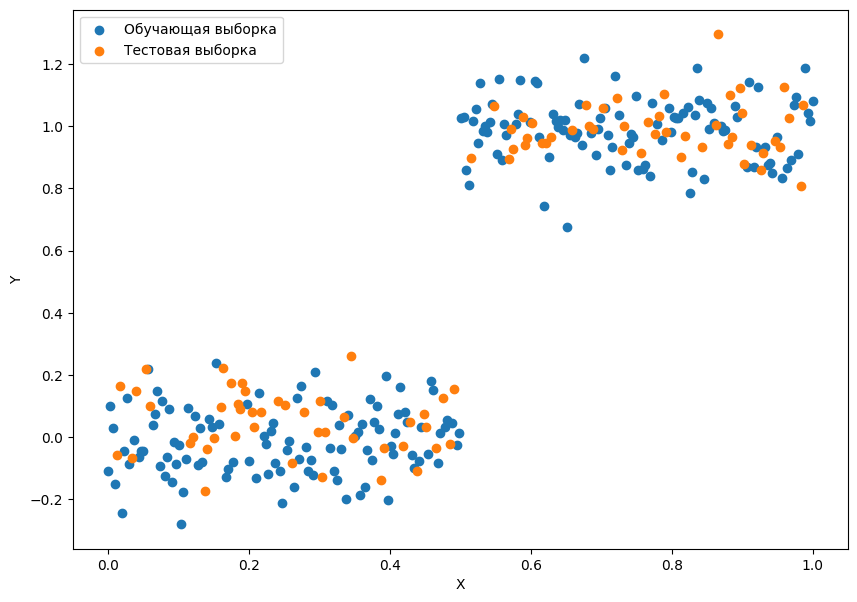

In [60]:
# Визуализация выборки
plt.figure(figsize = (10, 7))
plt.scatter(X_train, y_train, label = 'Обучающая выборка')
plt.scatter(X_test, y_test, label = 'Тестовая выборка')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend();

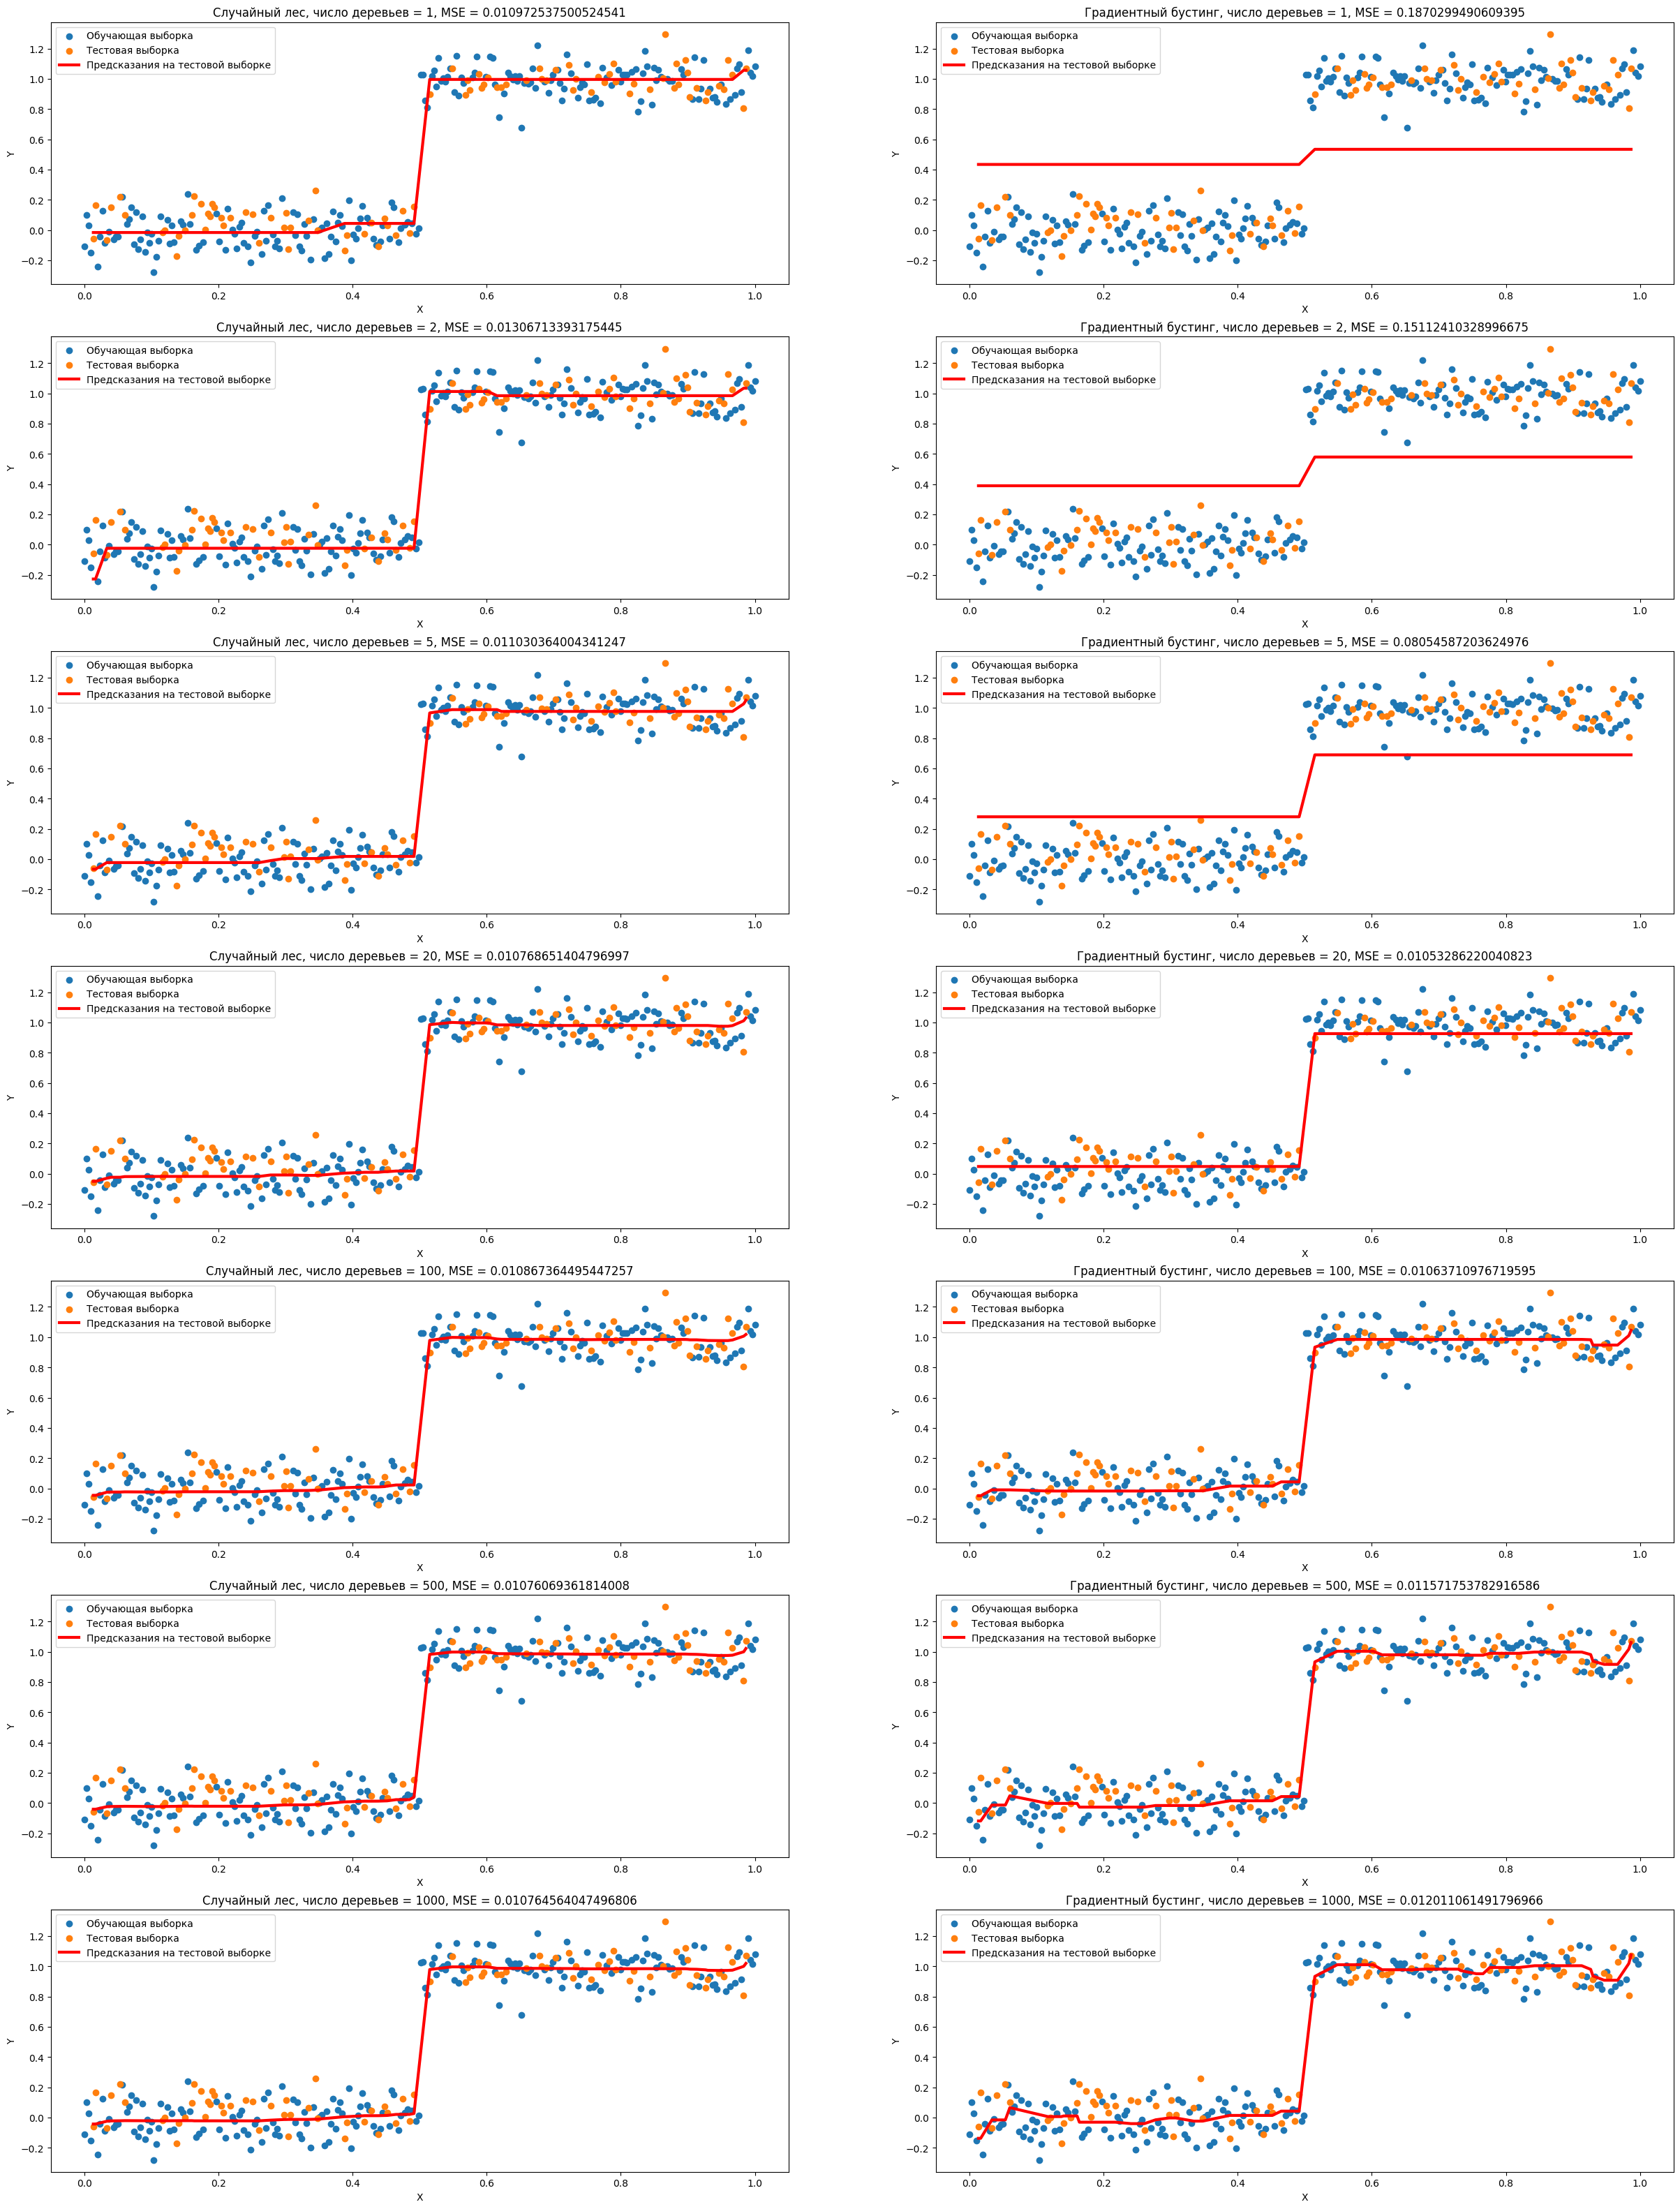

In [ ]:
# Визуализация решающих поверхностей
trees = [1, 2, 5, 20, 100, 500, 1000]

fig, ax = plt.subplots(len(trees), 2, figsize = (30, 40))

loss_rf_train = []
loss_gb_train = []
loss_rf_test = []
loss_gb_test = []

for i, ts in enumerate(trees):
    rf = RandomForestRegressor(n_estimators = ts, max_depth = 2)
    gb = GradientBoostingRegressor(n_estimators = ts, max_depth = 1, learning_rate = 0.1)
    
    rf.fit(X_train, y_train)
    ax[i, 0].scatter(X_train, y_train, label = 'Обучающая выборка')
    ax[i, 0].scatter(X_test, y_test, label = 'Тестовая выборка')
    ax[i, 0].plot(sorted(X_test), rf.predict(sorted(X_test)), lw = 3, c = 'red', label = 'Предсказания на тестовой выборке')
    ax[i, 0].set_xlabel('X')
    ax[i, 0].set_ylabel('Y')
    ax[i, 0].set_title('Случайный лес, число деревьев = ' + str(ts) + ', MSE = ' + str(mean_squared_error(y_test, rf.predict(X_test))))
    ax[i, 0].legend();
    
    loss_rf_train.append(mean_squared_error(y_train, rf.predict(X_train)))
    loss_rf_test.append(mean_squared_error(y_test, rf.predict(X_test)))
    
    gb.fit(X_train, y_train)
    ax[i, 1].scatter(X_train, y_train, label = 'Обучающая выборка')
    ax[i, 1].scatter(X_test, y_test, label = 'Тестовая выборка')
    ax[i, 1].plot(sorted(X_test), gb.predict(sorted(X_test)), lw = 3, c = 'red', label = 'Предсказания на тестовой выборке')
    ax[i, 1].set_xlabel('X')
    ax[i, 1].set_ylabel('Y')
    ax[i, 1].set_title('Градиентный бустинг, число деревьев = ' + str(ts) + ', MSE = ' + str(mean_squared_error(y_test, gb.predict(X_test))))
    ax[i, 1].legend();
    
    loss_gb_train.append(mean_squared_error(y_train, gb.predict(X_train)))
    loss_gb_test.append(mean_squared_error(y_test, gb.predict(X_test)))

Как мы видим, решающая поверхность случайного леса не изменяется при достижении определённого числа деревьев, в то время как для бустинга она становится всё более сложной.

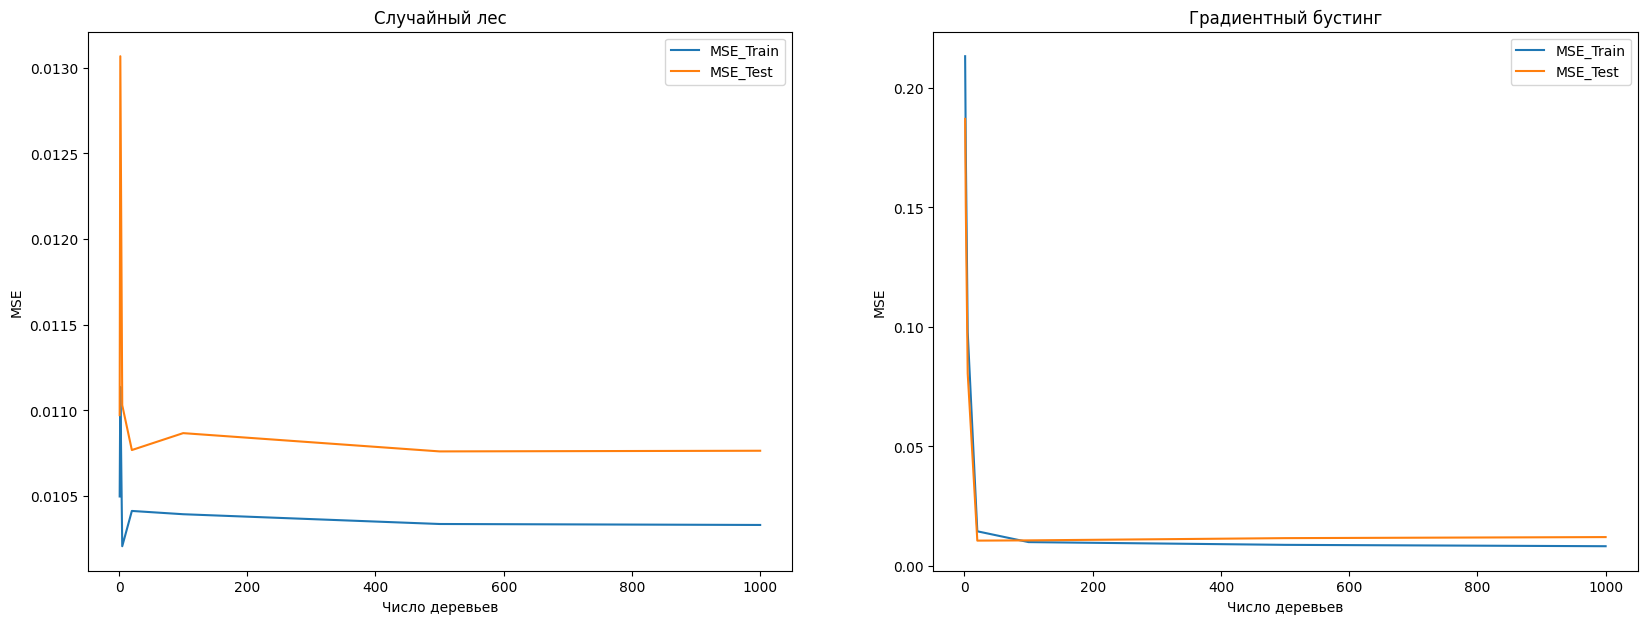

In [62]:
# Визуализация ошибок
fig, ax = plt.subplots(1, 2, figsize = (20, 7))

ax[0].plot(trees, loss_rf_train, label = 'MSE_Train')
ax[0].plot(trees, loss_rf_test, label = 'MSE_Test')
ax[0].set_xlabel('Число деревьев')
ax[0].set_ylabel('MSE')
ax[0].set_title('Случайный лес')
ax[0].legend()

ax[1].plot(trees, loss_gb_train, label = 'MSE_Train')
ax[1].plot(trees, loss_gb_test, label = 'MSE_Test')
ax[1].set_xlabel('Число деревьев')
ax[1].set_ylabel('MSE')
ax[1].set_title('Градиентный бустинг')
ax[1].legend();

Поведение ошибок для случайного леса совпадает с тем, которое мы видели на предыдущем семинаре. В случае бустинга ошибка на тренировочной выборке стабильно убывает, а на тестовой – возрастает, что вероятно говорит об (очень быстром) переобучении. Если же мы аккуратно подберём гиперпараметры для деревьев и длину шага, то сможем добиться типичной U-образной формы функции потерь на тестовой выборке.

В качестве способа регуляризации также может использоваться сокращение шага:

$$
a^{(N)}(X) = a^{(N-1)}(X) + \alpha w_N b^{(N)}(X),
$$

где $\alpha \in (0, 1]$ – темп обучения, или стохастический градиентный бустинг.

**Важный момент:** примеры выше демонстрируют, насколько быстро бустинг может переобучаться, и как в его случае важен подбор гиперпараметров. В связи с этим может сложиться ситуация, что градиентный бустинг с дефолтными параметрами показывает более плохое качество, чем, например, случайный лес с дефолтными параметрами, однако хорошо настроенный градиентный бустинг [обычно превосходит](https://www.quora.com/How-can-the-performance-of-a-Gradient-Boosting-Machine-be-worse-than-Random-Forests) случайный лес по качеству. Важна и конкретная реализация бустинга: например, [здесь](https://towardsdatascience.com/boosting-showdown-scikit-learn-vs-xgboost-vs-lightgbm-vs-catboost-in-sentiment-classification-f7c7f46fd956), представлено очень хорошее сравнение различных имплементаций. 

#### 4.3 Пара слов о смещении и дисперсии.

Вспомним, что в случайном лесе в качестве базовых моделей мы брали переобученные деревья, мотивируя это тем, что бэггинг позволит сохранить низкое смещение и при этом уменьшить дисперсию. Бустинг по построению работает проивоположно: композиция обладает более низким, чем базовые модели, смещением, но такой же или большей дисперсией (ещё раз проговорите последовательность построения бустинга, и вы увидите, почему это так). Поэтому в качестве базовых моделей для бустинга обычно используются модели с высоким смещением и низкой дисперсией – как мы знаем, такие модели являются недообученными – например, неглубокие решающие деревья.

### 5. Тестирование градиентного бустинга на разных данных

На прошлом семинаре мы выяснили, что случайный лес с дефолтными гиперпараметрами превосходит другие изученные нами алгоритмы на разных типах данных. Попробуем на тех же данных сравнить случайный лес и градиентный бустинг. 

**Важное замечание:** скорее всего, бустинг с дефолтными гиперпараметрами будет показывать более плохое качество, чем случайный лес с дефолтными гиперпараметрами – ключевую роль в бустинге играет подбор гиперпараметров. В дополнение, сравнение различных имплементаций по ссылке выше показывает, что реализация `sklearn` может оказаться не самой удачной по качеству (спорный вопрос!). Поэтому попробуйте провести как можно больше экспериментов и подобрать такие гиперпараметры для бустинга, чтобы превзойти случайный лес по качеству.

**Внимание:** в этой части вам предстоит скачивать объёмные наборы данных. Не забудьте удалить их после семинара, если не планируете использовать их в дальнейшем, чтобы они не занимали лишнее место на вашем компьютере.

**! Модели могут обучаться очень-очень долго.**

#### 5.1 Бинарная классификация на примере [Kaggle Predicting a Biological Response](https://www.kaggle.com/c/bioresponse/data?select=train.csv)

In [63]:
# Загрузка данных
!wget  -O 'kaggle_response.csv' -q 'https://www.dropbox.com/s/uha70sej5ugcrur/_train_sem09.csv?dl=1'

In [64]:
data = pd.read_csv('kaggle_response.csv')
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 123)

In [65]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score

# TODO: обучите градиентный бустинг и случайный лес с дефолтными параметрами
# Сравните их AUC ROC на тестовой выборке
# gb = GradientBoostingClassifier()
# gb.fit(X_train, y_train)
# pred_gb = gb.predict_proba(X_test)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict_proba(X_test)

# TODO: попробуйте настроить градиентный бустинг так, чтобы превзойти случайный лес по качеству
gb = GradientBoostingClassifier(n_estimators = 500, learning_rate = 0.1, max_depth = 10, loss = 'exponential')
gb.fit(X_train, y_train)
pred_gb = gb.predict_proba(X_test)

In [66]:
roc_auc_score(y_test, pred_gb[:, 1])

0.8761666793825182

In [67]:
roc_auc_score(y_test, pred_rf[:, 1])

0.875524528877699